# Case: Mental Health Treatment

This project applies supervised and unsupervised machine learning to a public mental health survey dataset: predicting whether a respondent has sought mental health treatment, and exploring whether respondents form natural groups.

It was developed as the final project for the Machine Learning II module of Santander Coders 2023 (Ada's Data Science program). The analysis is exploratory and academic in scope — it is not intended for clinical screening or individual-level decisions.

*Approach:* exploratory data analysis (univariate, bivariate, Chi-squared tests) → data treatment (proportional imputation) → supervised modeling (XGBoost in a preprocessing pipeline, threshold analysis, feature importance) → unsupervised exploration (K-Means and DBSCAN, assessed with silhouette and Davies-Bouldin scores).

*Dataset:* public, available on Kaggle under the MIT license (2014–2015 survey data).
Responsible data note: mental health is a sensitive domain; the results are dataset-specific patterns, not diagnostic indicators.


**1. About the Project and the Dataset**
* Presentation of the project objectives.
* Presentation of the chosen dataset.

**2. Exploratory Data Analysis (EDA)**
* Univariate and bivariate analysis to understand the distribution of and relationship between the variables.
* Statistical tests (such as Chi-squared) to examine associations between categorical variables and the target variable *treatment*.

**3. Data Treatment**
* Handling of null values in the self_employed column using proportional imputation.
* Removal of columns that will not be used in modeling.

**4. Data Preparation for Supervised Modeling**
* Separation of explanatory variables (X) and target variable (y).
* Encoding of categorical variables using *BinaryEncoder*.
   * Test using OneHotEncoder and class balancing with SMOTE.
* Splitting the data into training and test sets.

**5. Supervised Modeling**
* Use of the XGBoost model within a pipeline that includes preprocessing and the classifier.
* Model evaluation using metrics such as accuracy and AUC-ROC.
* Feature-importance analysis to understand which characteristics have the greatest impact on prediction.

**6. Optimization and Tuning of the Supervised Model**
* Parameter tuning using techniques such as GridSearchCV.
* Experimentation with different classification thresholds to balance precision and recall.
* Charts to visualize missing data, feature importance, and confusion matrices for model evaluation.

**7. Conclusions and Notes on the Supervised Model**
* Conclusions about the models and their applications.
* Notes on possible improvements.
* Brief conclusions on the feature-importance analysis.

**8. Data Preparation for Unsupervised Modeling**
* Separation of explanatory variables (X).
* Encoding of categorical variables using *OneHotEncoder*.
* Normalization of the data so that all variables are on the same scale.

**9. Unsupervised Modeling — K-Means**
* Application of clustering algorithms such as K-Means and DBSCAN.
* Evaluation of the resulting clusters using metrics such as the Silhouette Coefficient and the Davies-Bouldin Index.
* Cluster visualization using dimensionality-reduction techniques such as PCA or t-SNE.

**10. Optimization and Tuning of the K-Means Model**
* Tuning of clustering parameters (e.g. `k` for K-Means, `eps` and `min_samples` for DBSCAN).
* Experimentation with different parameter settings to improve cluster quality.
* Charts to visualize the cluster distribution and the amount of noise.

**11. Unsupervised Modeling — DBSCAN**
* Application of DBSCAN.
* Evaluation of the resulting clusters.
* Cluster visualization.

**12. Conclusions and Notes on the Unsupervised Models**
* Conclusions on the quality of the resulting clusters and their interpretation.
* Notes on improvements to the models and the parameters used.

# 1. About the Project and the Dataset

## 1.1. Objectives

#### General
Develop and evaluate a supervised machine learning model (SVM or ensembles) and an unsupervised model to solve a classification problem, optimizing their hyperparameters and comparing their performance based on appropriate evaluation metrics.

#### Specific
* Choose and present the dataset.
* Conduct exploratory data analysis.
* Define the **target** variable and justify the choice.
* Implement the models.
* Optimize hyperparameters.
   - Optimize each model's hyperparameters using a search heuristic, such as grid search or random search, making the method used explicit.
* Evaluate the models.
   - Evaluate the models using classification evaluation metrics, focusing on preventing overfitting through the use of a test set.
* Compare and analyze the results.
   - Compare the results obtained by each model after hyperparameter optimization and assess which model performs best, based on the evaluation metrics studied and explaining how these metrics were interpreted to reach a conclusion about model performance.

## 1.2. About the Global Mental Health Trends dataset

**Mental Health Dataset** - *Mental Health: Understanding the Factors that Affect Mental Health*

According to the dataset description on Kaggle: "*This dataset records a global survey conducted to track mental health trends. The data covers a range of variables, such as stress levels, depression, anxiety, subjective well-being, and use of mental health services. The survey involved respondents from diverse demographic backgrounds, including gender, employment status, and geographic region. This dataset aims to provide a better understanding of changes in mental health globally over the specified period*" (free translation).

Although this is not explicitly stated, the data is from 2014 and 2015.

Available on <a href='https://www.kaggle.com/datasets/divaniazzahra/mental-health-dataset'>Kaggle under the MIT license</a>, it provides a public resource for detailed analyses and the development of predictive models.

### More about the dataset
* **Survey goal:** The main goal of this dataset is to analyze mental health trends around the world, identifying significant patterns and correlations between different demographic and behavioral variables.

* **Variables included:** The dataset includes a series of variables capturing information on stress, depression, anxiety, subjective well-being, and use of mental health services. In addition, it collects demographic data such as gender, occupation, whether the individual is self-employed, and whether they have a family history of mental health problems.

### Variable detail

* **Demographic:** Respondents' gender, country, and occupation.
* **Behavioral and mental health:** Whether the respondent is self-employed, their family mental health history, whether they have received mental health treatment, the estimated number of days spent indoors, perceived stress level, changes in habits or sleep patterns, history of mental health disorders, mood swings, difficulty coping with pressure, interest at work, social difficulties, willingness to be interviewed about mental health, and awareness or use of care options.
    * **Stress, depression, and anxiety levels:** Assess participants' emotional state using standardized scales.
    * **Subjective well-being:** Reflects the individual's perception of their quality of life and satisfaction with different aspects of life.
    * **Use of mental health services:** Reports on the frequency and type of access to mental health services, including psychotherapy, medication, and other resources.

### Relevance for research
This dataset is especially relevant for the development of public health policies, the design of workplace support programs, and for academia, as it enables a detailed analysis of mental health conditions across diverse social and cultural contexts. Through its analysis, it is possible to identify risk factors, evaluate the effectiveness of different types of interventions, and improve the overall understanding of global mental health.

#### Features

The dataset documentation describes 17 features, presented in the table below:

| Column | Description |
|---|---|
| Timestamp | Date and time of the survey response |
| Gender | Respondent's gender |
| Country | Country where the respondent lives |
| Occupation | Respondent's occupation or profession |
| self_employed | Whether the respondent is self-employed |
| family_history | Whether there is a family history of mental health problems |
| treatment | Whether the respondent has received treatment or therapy for mental health problems |
| Days_Indoors | Estimated number of days per week the respondent spends indoors |
| Growing_Stress | Respondent's current stress level |
| Changes_Habits | Whether the respondent experienced changes in habits or sleep patterns |
| Mental_Health_History | Whether the respondent has a history of mental health disorders |
| Mood_Swings | Whether the respondent experiences sudden mood swings |
| Coping_Struggles | Whether the respondent has difficulty coping with pressure or stress |
| Work_Interest | Respondent's level of interest and motivation at work |
| Social_Weakness | Whether the respondent has difficulty interacting socially or maintaining relationships |
| mental_health_interview | Whether the respondent is willing to be interviewed about their mental health |
| care_options | Whether the respondent is aware of or uses mental health care options |

### On the choice of this dataset
Since the start of the course I had been considering using a dataset in the mental health field, a topic that interests me greatly. I had been working with firearms-related datasets, another topic of interest and one in which I have a bit more experience analyzing data.
For this final assignment, I decided to challenge myself and look for a dataset in the mental health field. I chose this one because, besides its Kaggle usability rating of 10, it can be a good resource for machine learning work, since it allows me to:

* **Identify patterns and trends:** Understand how mental health evolved globally over the period analyzed.
* **Develop predictive models:** Build models that identify individuals at higher risk of developing mental health problems, based on demographic data and well-being indicators.
* **Assess the effectiveness of interventions:** Analyze the impact of mental health policies and programs on reducing the prevalence of disorders and improving well-being.
* Finally, the richness of information and the global scope of the dataset make it an interesting instrument for studies on mental health.

## 1.3. References used in preparing this project
- Module community and content: Ada
- Scikit-learn. **Scikit-learn: Machine Learning in Python**. Available at: https://scikit-learn.org/stable/index.html. Accessed: May 18, 2024.

In [1]:
# Standard libraries and data manipulation
import pandas as pd
import numpy as np
import re
from unidecode import unidecode

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing and Modeling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Machine Learning - Models and Encoders
import xgboost as xgb
import category_encoders as ce
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# Statistics
from scipy.stats import chi2_contingency

# Warnings
import warnings

# Logging configuration
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Constants
SEED = 42

# 2. Exploratory Data Analysis (EDA)

**Define helper functions to be used in the analysis**

In [2]:
def clean_column_names(df):
    """
    Cleans and standardizes the column names of a DataFrame.
    - Removes accents.
    - Converts to lowercase.
    - Replaces non-alphanumeric characters with underscores.
    - Removes extra spaces.
    Parameters:
        df (pd.DataFrame): DataFrame whose column names will be cleaned.
    Returns:
        pd.DataFrame: DataFrame with cleaned column names.
    """
    df.columns = [unidecode(col).lower() for col in df.columns]  # Remove accents and convert to lowercase
    df.columns = [re.sub(r'\W+', '_', col) for col in df.columns] # Replace non-alphanumeric characters with _
    df.columns = [col.replace(' ', '') for col in df.columns] # Remove spaces
    return df

def transform_timestamp(df, timestamp_col):
    """
    Transforms a timestamp column into datetime and creates new columns for month-year and year.

    Parameters:
        df (pd.DataFrame): DataFrame containing the timestamp column.
        timestamp_col (str): Name of the timestamp column to transform.

    Returns:
        pd.DataFrame: DataFrame with the original timestamp column converted to datetime,
                      and two new columns 'month_year' and 'year' added.
    """
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    df['month_year'] = df[timestamp_col].dt.to_period('M')
    df['year'] = df[timestamp_col].dt.to_period('Y')
    return df

def plot_categorical_distribution(df, category_list, palette = 'Set2', figsize = (14, 4)):
    """
    Creates distribution plots for each categorical variable in the DataFrame.
    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        category_list (list): List of column names of categorical data to plot.
        palette (str or sns.color_palette, optional): Color palette to use for the plots.
        figsize (tuple, optional): Figure size for each plot.
    """
    for var in category_list:
        plt.figure(figsize=figsize)
        sns.countplot(x=var, data=df, palette=palette)
        plt.title(f'Distribution of "{var}"')
        plt.xticks(rotation=70)
        plt.show()

def plot_time_distribution(df, time_vars, plot_type = 'frequency', figsize=(10, 4), palette='Set2'):
    """
    Creates plots for time-related variables in the DataFrame, either as frequency distributions or as time trends.
    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        time_vars (dict): Dictionary where keys are column names and values are plot titles.
        plot_type (str, optional): Type of plot, either 'frequency' for frequency distribution or 'trend' for time trend.
        figsize (tuple, optional): Figure size for each plot.
        palette (str or sns.color_palette, optional): Color palette to use for the plots.
    """
    for var, title in time_vars.items():
        counts = df[var].value_counts().sort_index()
        plt.figure(figsize = figsize)
        if plot_type == 'frequency':
            sns.barplot(x=counts.index.astype(str), y = counts.values, palette=palette)
        elif plot_type == 'trend':
            counts.plot(kind='line', marker = 'o', linestyle = '-', color = palette[0]) 
        plt.xticks(rotation=70)
        plt.title(title)
        plt.xlabel(var)
        plt.ylabel('No. of entries')
        plt.grid(True)
        plt.show()
        
def bivariate_analysis(df, target_var, vars_to_analyze, top_countries=None):
    """
    Performs bivariate analysis between the target variable and a list of categorical variables.
    For each variable, the function creates a contingency table, a stacked bar chart, and performs a Chi-squared test.
    Parameters:
      df (DataFrame): The DataFrame containing the data.
      target_var (str): The name of the target variable.
      vars_to_analyze (list): A list of names of categorical variables to analyze.
    Returns:
        None: This function does not return any value. It displays contingency tables, charts, and test results directly.
    """
    # Filter the DataFrame to include only records from the most frequent countries, if specified
    if top_countries is not None:
        top_countries_list = df['country'].value_counts().nlargest(top_countries).index
        df = df[df['country'].isin(top_countries_list)]
        print(f'Analysis for the {top_countries} most frequent countries.')

    for var in vars_to_analyze:
        # Contingency table
        contingency_table = pd.crosstab(df[target_var], df[var])
        print(f'Contingency table of {target_var} and {var} \n {contingency_table}')
        
        # Stacked bar chart
        contingency_table.plot(kind = 'bar', stacked = True, figsize=(14, 3))
        plt.title(f'{target_var} by {var}')
        plt.xlabel(target_var)
        plt.ylabel('Count')
        plt.show()
            
        # Chi-squared test
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f'Chi-squared test for {var} and {target_var}:')
        print(f'Chi-squared: {chi2}, p-value: {p}\n')

## 2.1. Dataset description

In [3]:
# Load data as a pandas DataFrame
df = pd.read_csv('MentalHealthDataset.csv')

In [4]:
# Preview dataset

# First rows
df.head(12)

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
5,8/27/2014 11:49,Female,Poland,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Not sure
6,8/27/2014 11:51,Female,Australia,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
7,8/27/2014 11:52,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
8,8/27/2014 12:18,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
9,8/27/2014 12:37,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No


In [5]:
# Last rows
df.tail(12)

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
292352,2/24/2015 9:18,Male,Canada,Business,No,No,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292353,2/24/2015 10:32,Male,United States,Business,No,No,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292354,4/2/2015 15:47,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292355,4/11/2015 14:35,Male,Poland,Business,Yes,No,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292356,4/23/2015 14:03,Male,Ireland,Business,No,No,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292357,5/6/2015 10:14,Male,Australia,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292358,5/6/2015 16:55,Male,United States,Business,No,No,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292359,7/27/2015 23:25,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292360,8/17/2015 9:38,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292361,8/25/2015 19:59,Male,United States,Business,No,Yes,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No


In [6]:
# Check structure and info of the df
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

The DF has
- 17 columns with dtype 'object'
- 292,364 rows

In [7]:
# Make a copy of df
df_original = df.copy()

# Rename and reorganize columns
df = clean_column_names(df)

df

,timestamp,gender,country,occupation,self_employed,family_history,treatment,days_indoors,growing_stress,changes_habits,mental_health_history,mood_swings,coping_struggles,work_interest,social_weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292359,7/27/2015 23:25,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292360,8/17/2015 9:38,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292361,8/25/2015 19:59,Male,United States,Business,No,Yes,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292362,9/26/2015 1:07,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes


## 2.2. First look at the target variable: treatment

Since the focus of this project relates to exploring the direct impact of practical interventions on mental health, "treatment" was the chosen target, as it focuses on those who actively sought treatment. This is essential for improving access to and the quality of mental health services. Below, I describe some aspects of the potential relevance of this choice:

* **Clinical and social relevance:** The decision to seek treatment is an important indicator of recognizing mental health problems and of the willingness to address them. Predicting this behavior can help identify barriers to accessing treatment and suggest targeted interventions to increase help-seeking.
* **Support for mental health public policy:** Models that help predict the likelihood of individuals seeking treatment can inform public health policy and corporate strategies to improve the access to and effectiveness of mental health services.
* **Organizational impact:** Understanding the factors that influence treatment-seeking can help institutions design better well-being programs, contributing to a healthier and more productive work environment.
* In addition, predicting who seeks treatment can help identify gaps in the availability of and access to mental health services, which is crucial for formulating effective public health and workplace well-being strategies.

In [8]:
# Check target
df['treatment'].value_counts(dropna = False, normalize = True)

treatment
Yes    0.504871
No     0.495129
Name: proportion, dtype: float64

## 2.3. Continuing the EDA

In [9]:
# Statistical summary of the variables
df.describe(include='object')

,timestamp,gender,country,occupation,self_employed,family_history,treatment,days_indoors,growing_stress,changes_habits,mental_health_history,mood_swings,coping_struggles,work_interest,social_weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


In [10]:
# Check null observations in each column
print('Null values in df: ', df.isnull().sum())

Null values in df:  timestamp                     0
gender                        0
country                       0
occupation                    0
self_employed              5202
family_history                0
treatment                     0
days_indoors                  0
growing_stress                0
changes_habits                0
mental_health_history         0
mood_swings                   0
coping_struggles              0
work_interest                 0
social_weakness               0
mental_health_interview       0
care_options                  0
dtype: int64


Up to this point I have found that:

* All variables are **dtype object**.
     * *timestamp* can be converted to **datetime**, which makes more sense for the analysis.

* There are 16 categorical variables and one date variable.

* The **self_employed column has 5,202 null entries** (approximately 1.8% of the entries). These values will be handled later.

In [11]:
# Transform the 'timestamp' column
df = transform_timestamp(df, 'timestamp')

## 2.4. Univariate Analysis

In [12]:
# Frequency of the variables
for var in df:
    print(f'Distribution of {var}:')
    print(df[var].value_counts())
    print('\n')

Distribution of timestamp:
timestamp
2014-08-27 11:43:00    2384
2014-08-27 12:31:00    2340
2014-08-27 12:53:00    1648
2014-08-27 16:21:00    1604
2014-08-27 12:39:00    1604
                       ... 
2014-08-27 23:54:00     390
2014-08-27 23:30:00     390
2014-08-27 23:14:00     390
2014-08-27 23:10:00     390
2016-02-01 23:04:00     390
Name: count, Length: 580, dtype: int64


Distribution of gender:
gender
Male      239850
Female     52514
Name: count, dtype: int64


Distribution of country:
country
United States             171308
United Kingdom             51404
Canada                     18726
Australia                   6026
Netherlands                 5894
Ireland                     5548
Germany                     4680
Sweden                      2818
India                       2774
France                      2340
Brazil                      2340
New Zealand                 1994
South Africa                1994
Switzerland                 1560
Israel                    

#### Categorical variables

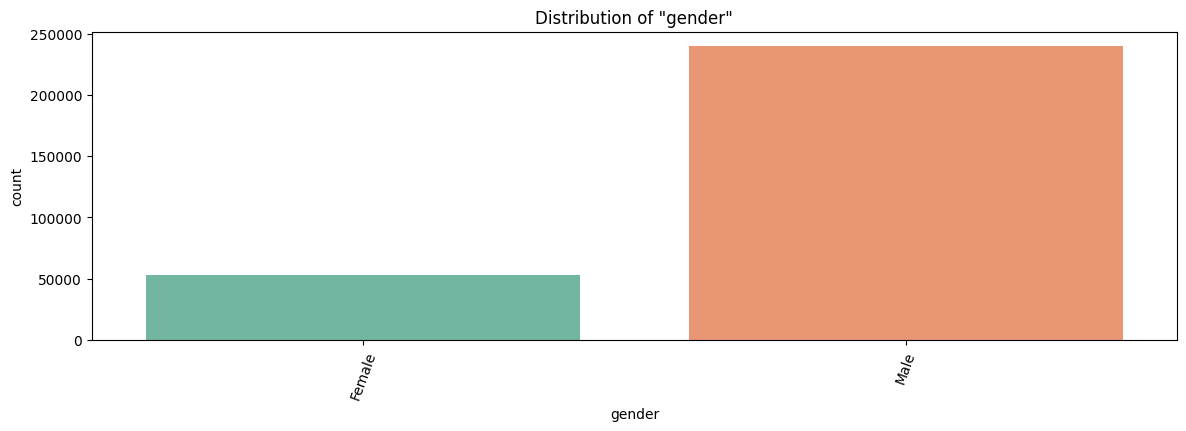

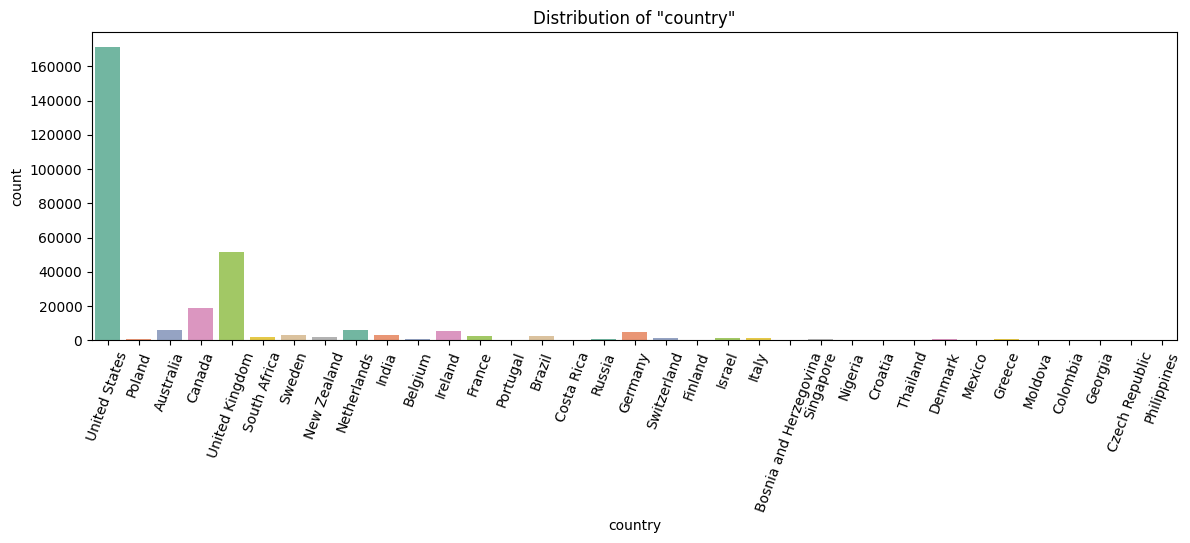

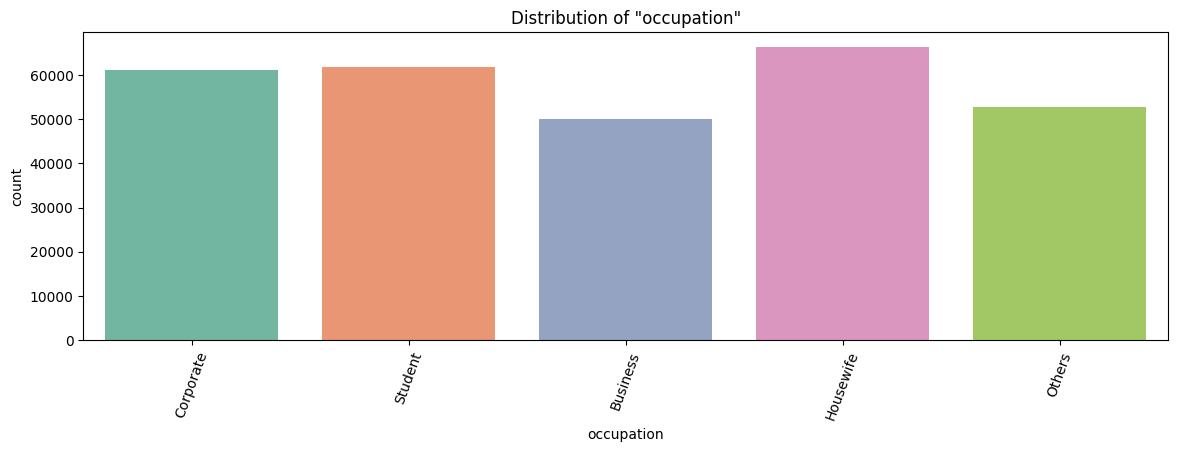

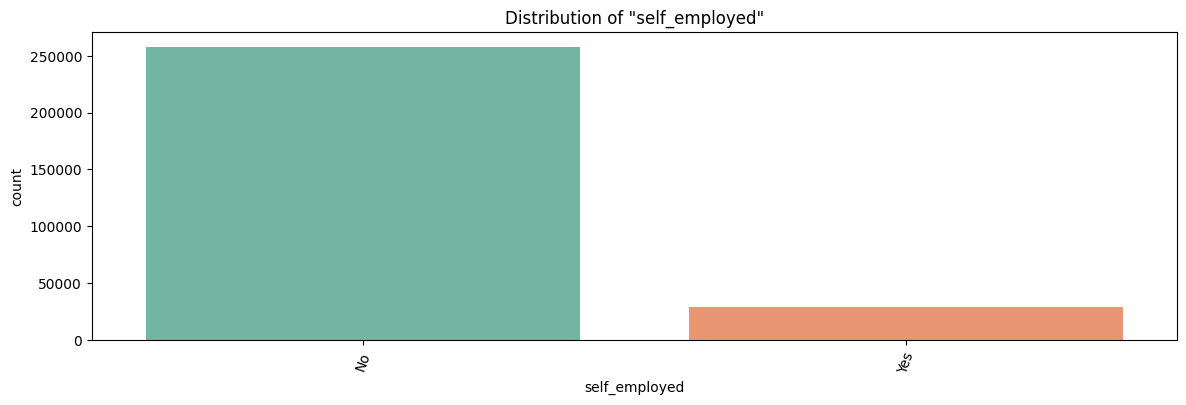

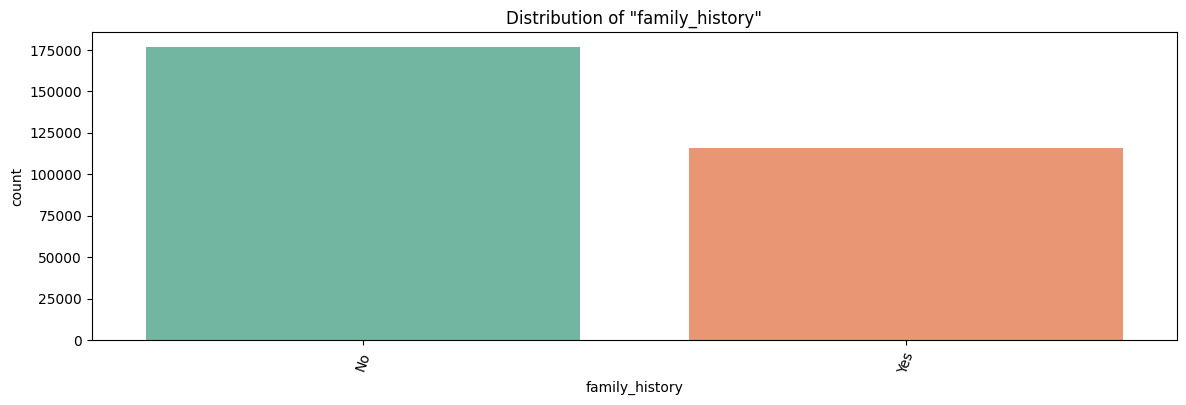

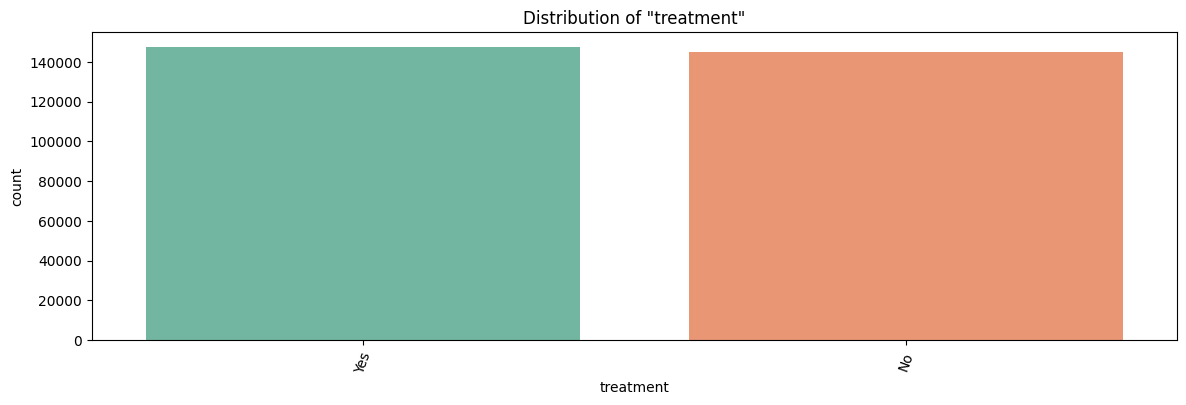

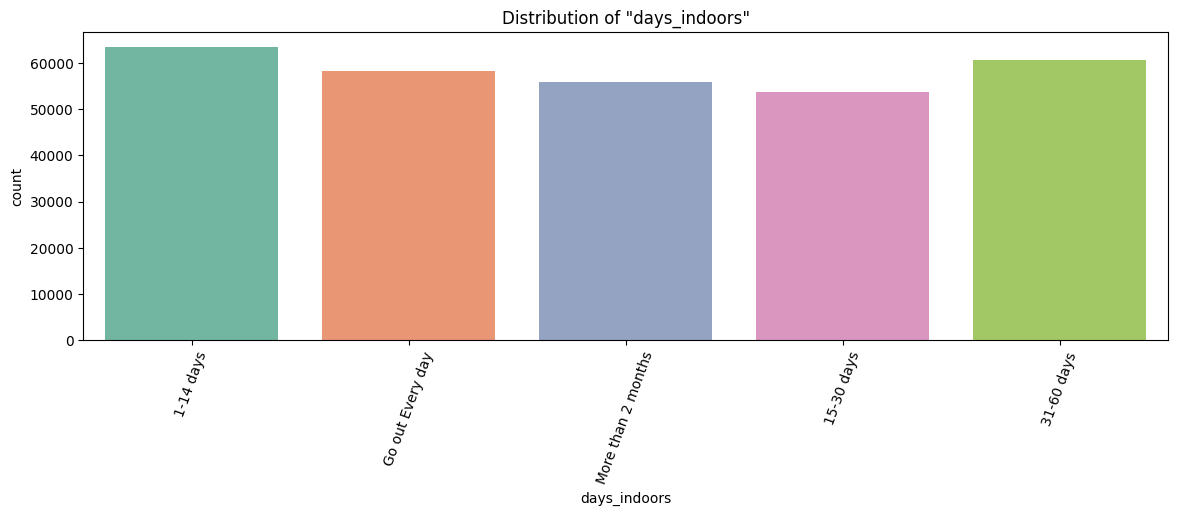

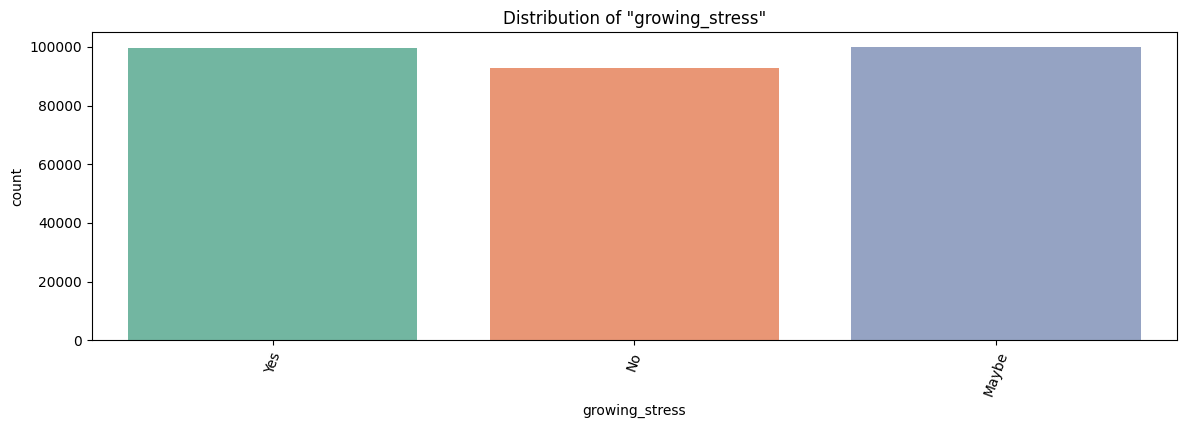

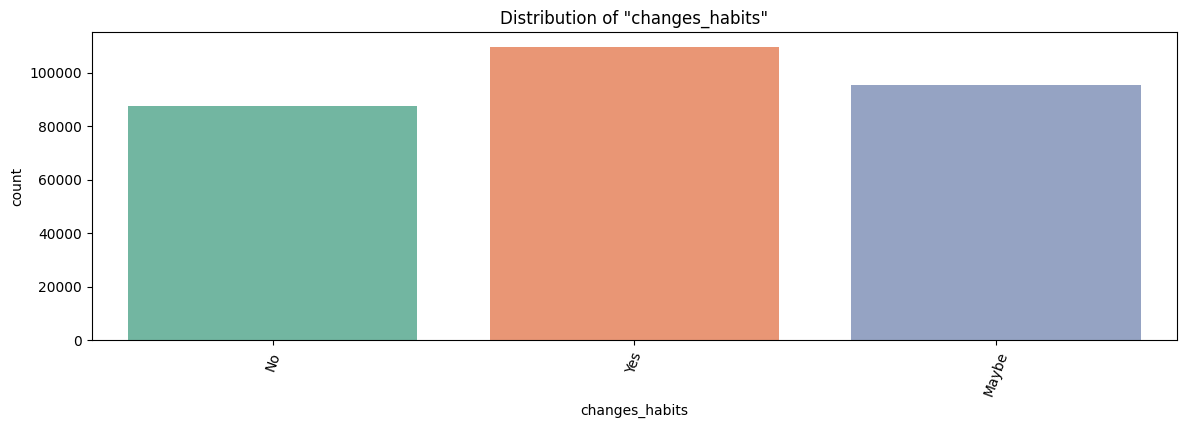

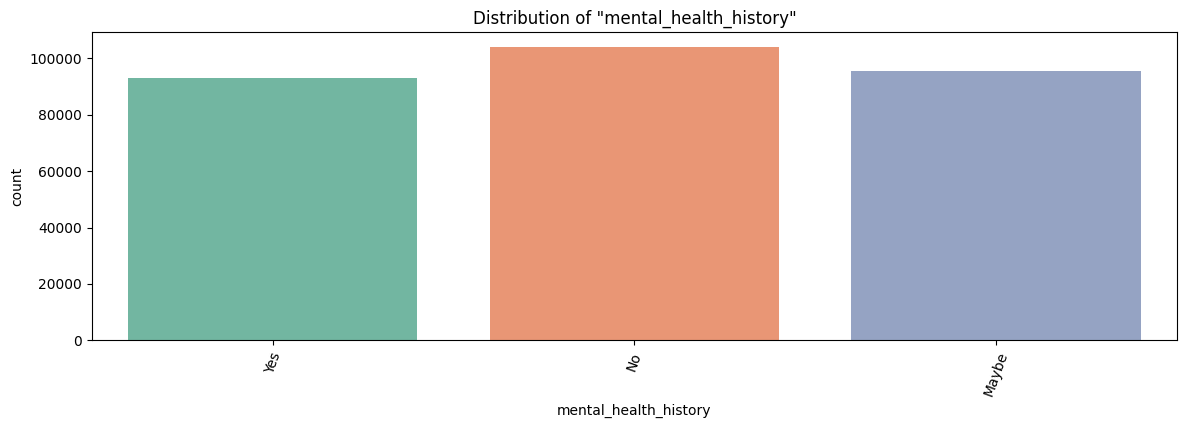

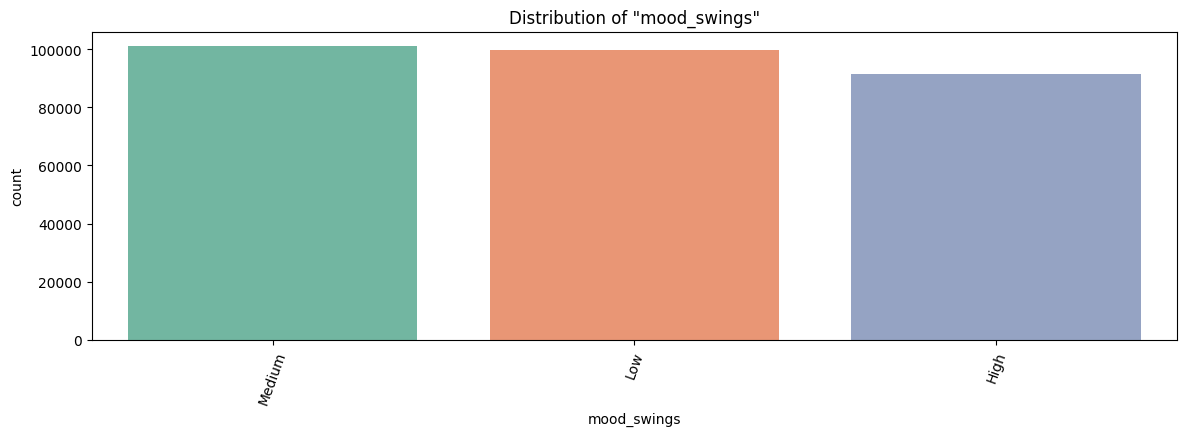

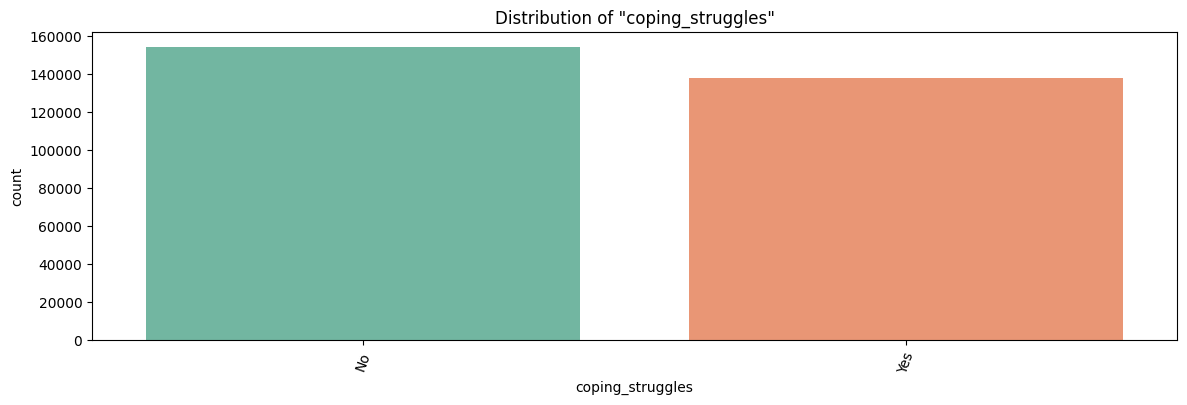

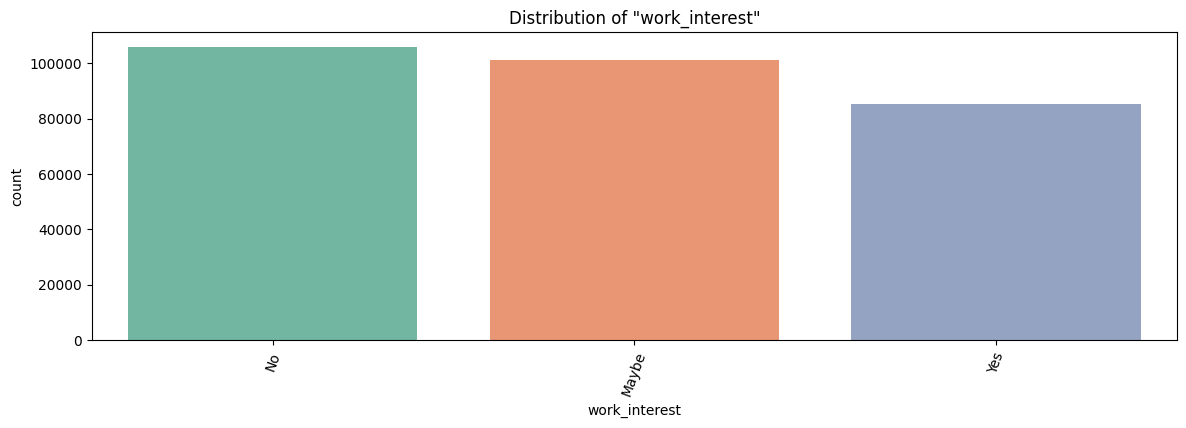

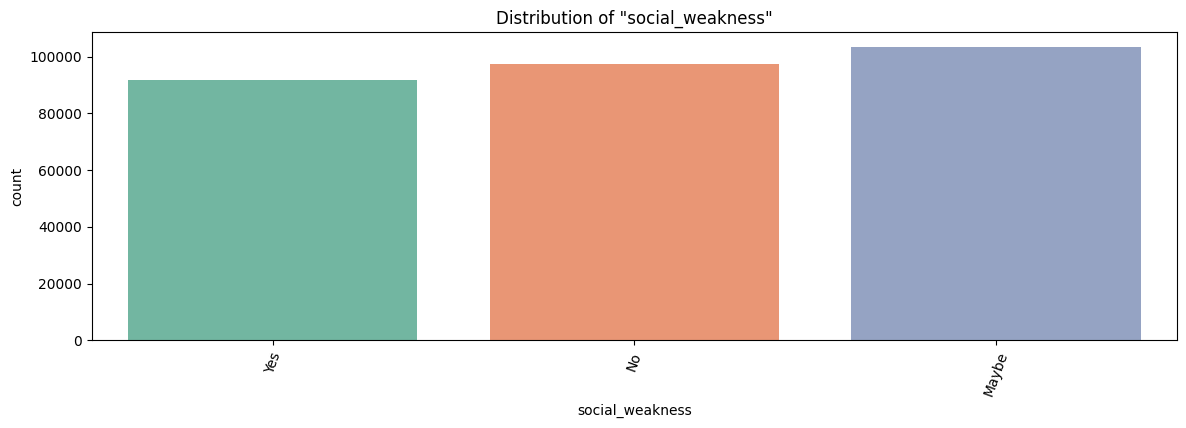

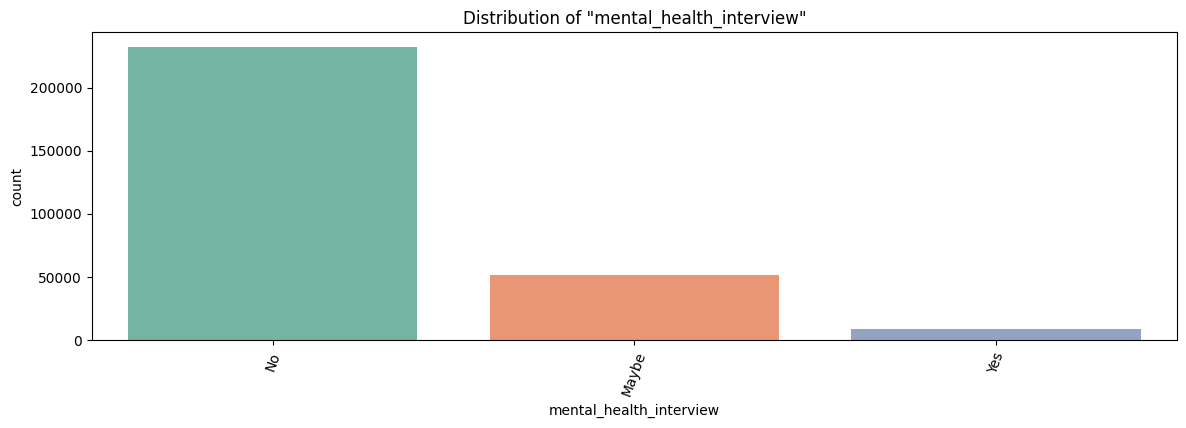

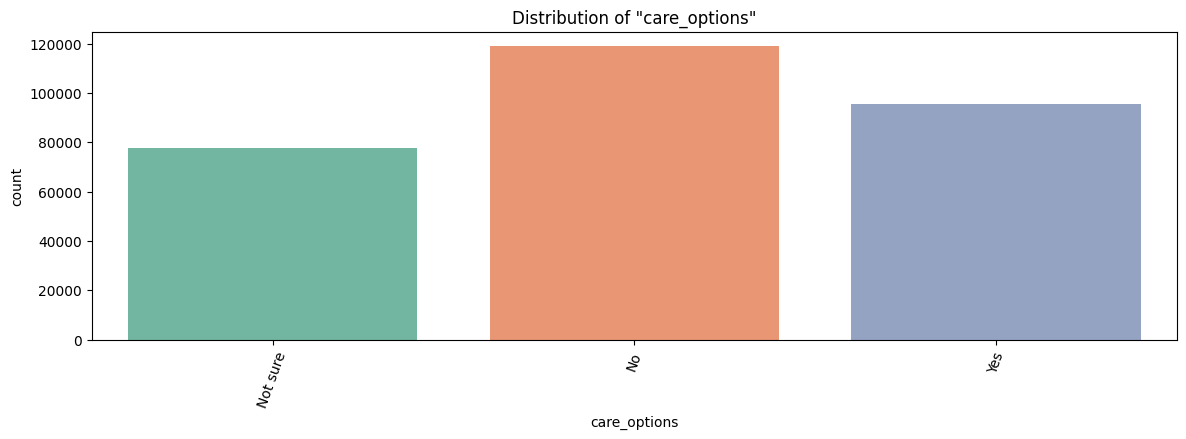

In [13]:
# Configure warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# List categorical variables
vars_cat = df.select_dtypes(include=['object'])

# Create a distribution plot for each categorical variable
plot_categorical_distribution(df, vars_cat.columns)

### Binary variables

In [14]:
# Identify binary variables
var_bin = []

for col in df.columns:
    if df[col].nunique() == 2:
        var_bin.append(col)

print(f'Binary variables: {var_bin}')
print(f'Total binary variables: {len(var_bin)} ({round(((len(var_bin)/17 * 100)), 2)}% of the dataset variables).')

Binary variables: ['gender', 'self_employed', 'family_history', 'treatment', 'coping_struggles']
Total binary variables: 5 (29.41% of the dataset variables).


### Date-type variables: 'month_year' and 'year'

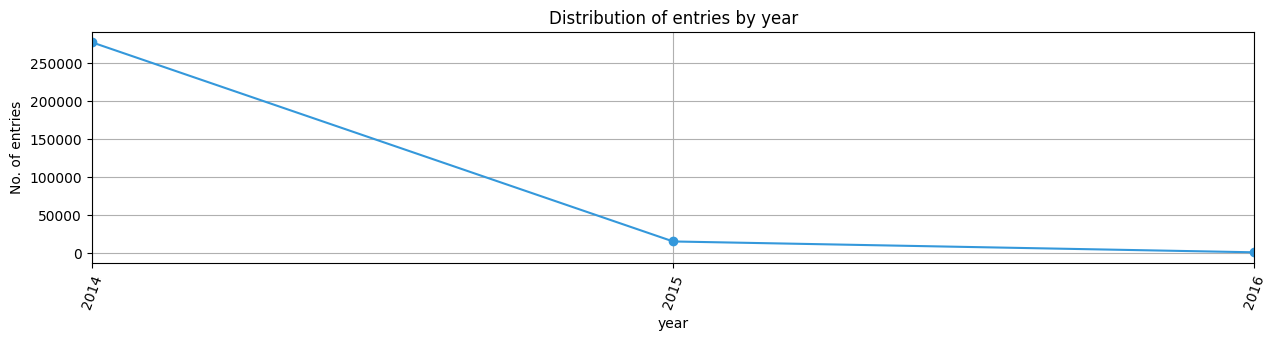

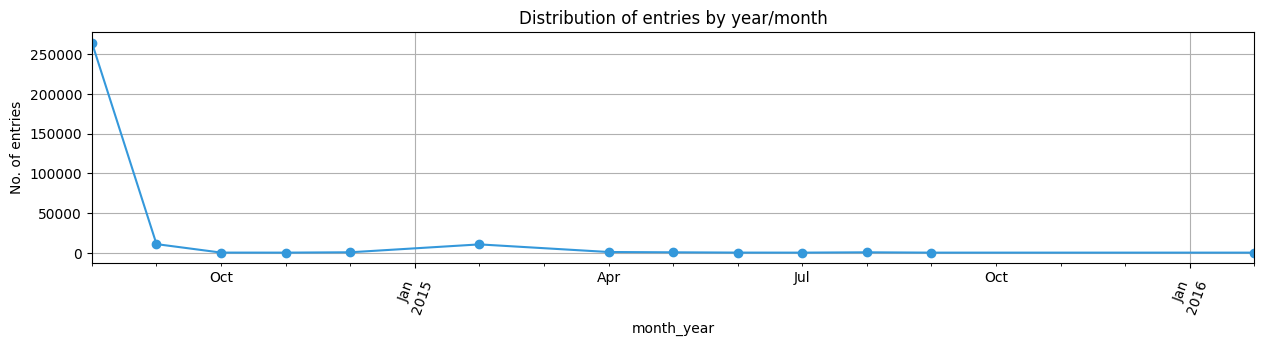

In [15]:
# Distribution of entries by year and by month/year

time_vars = {
    'year': 'Distribution of entries by year',
    'month_year': 'Distribution of entries by year/month'
}
plot_time_distribution(df, time_vars, plot_type='trend', figsize=(15, 3), palette=['#3498db'])

2026-06-22 09:46:34,742 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-22 09:46:34,745 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


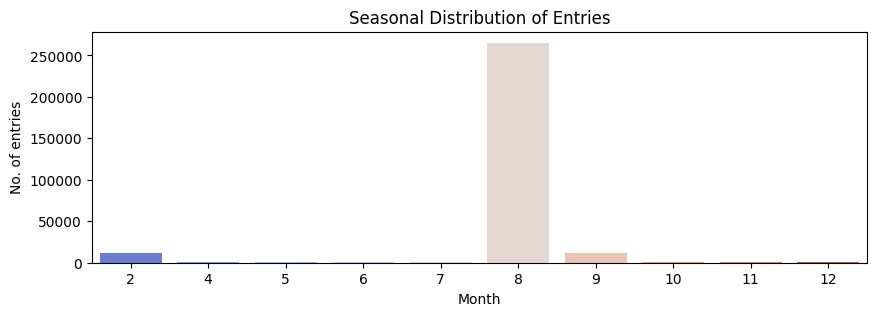

In [16]:
# Distribution of entries by month
# Extract only the month for seasonal analysis
df['month'] = df['timestamp'].dt.month

# Frequency count by month
monthly_counts = df['month'].value_counts().sort_index()

# Plot the monthly distribution
plt.figure(figsize=(10, 3))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='coolwarm')
plt.title('Seasonal Distribution of Entries')
plt.xlabel('Month')
plt.ylabel('No. of entries')
plt.show()

A large concentration of survey responses is observed in August 2014, with two smaller peaks in September 2014 and February 2015.

- Since these variables relate to the survey response date and not to specific dates tied to the other variables, I chose to drop them in the modeling stage.

- Although including temporal variables can help capture seasonal effects or trends that matter in predictive models, in this case the temporal variables refer to the survey response and not to the variables related to predicting the target.

- Keeping these variables would introduce a misleading temporal bias into the analysis and the prediction.

## 2.5. Bivariate Analysis

Since the target variable is *treatment*, I next examine the correlation between pairs of variables to see which factors may influence *treatment*, based on the following questions:

* **Gender and treatment:** are there significant differences in the likelihood of seeking treatment across genders?

* **family_history and treatment:** how might a family history of mental health problems influence the likelihood of seeking treatment? Are individuals with a family history more likely to seek help?

* **self_employed and treatment:** is there a difference in the tendency to seek treatment between self-employed workers and those employed by companies? Can self-employment status influence access to mental health resources?

* **country and treatment:** are there geographic variations in mental health treatment? (which could, for example, reflect cultural differences or differences in service availability).

* **occupation and treatment:** are certain professions associated with higher rates of treatment-seeking? Could this relate to workplace stress levels?

* **days_indoors and treatment:** is there a correlation between time spent indoors and treatment-seeking?

* **growing_stress and treatment:** are higher stress levels correlated with a higher likelihood of seeking treatment?

* **changes_habits and treatment:** are changes in habits or sleep patterns correlated with treatment-seeking?

To perform this analysis, for each *treatment* + variable pair I created:
* Contingency tables
* Stacked bar charts
* Mosaics for each pair of variables;
* And I ran a Chi-squared hypothesis test to check whether there is a significant relationship between them.

Analysis for the 10 most frequent countries.
Contingency table of treatment and gender 
 gender     Female    Male
treatment                
No          15624  115050
Yes         35154  105690


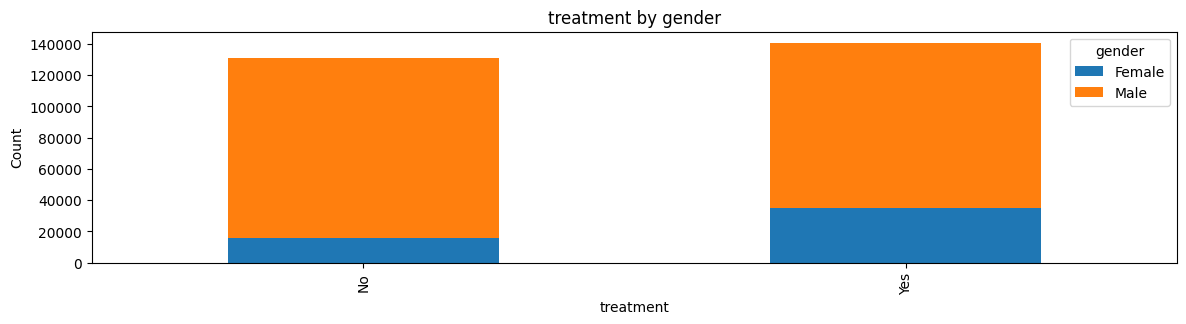

Chi-squared test for gender and treatment:
Chi-squared: 7537.2209765385005, p-value: 0.0

Contingency table of treatment and family_history 
 family_history      No    Yes
treatment                    
No              101242  29432
Yes              60292  80552


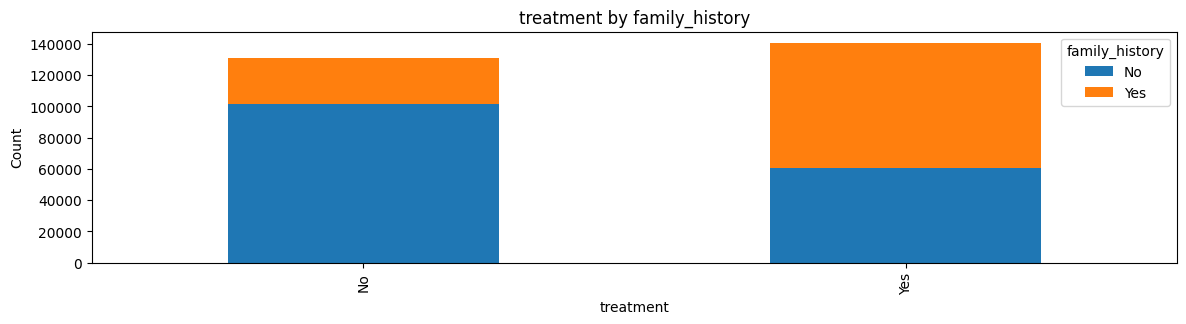

Chi-squared test for family_history and treatment:
Chi-squared: 33806.49010322003, p-value: 0.0

Contingency table of treatment and self_employed 
 self_employed      No    Yes
treatment                   
No             117024  11310
Yes            124068  13914


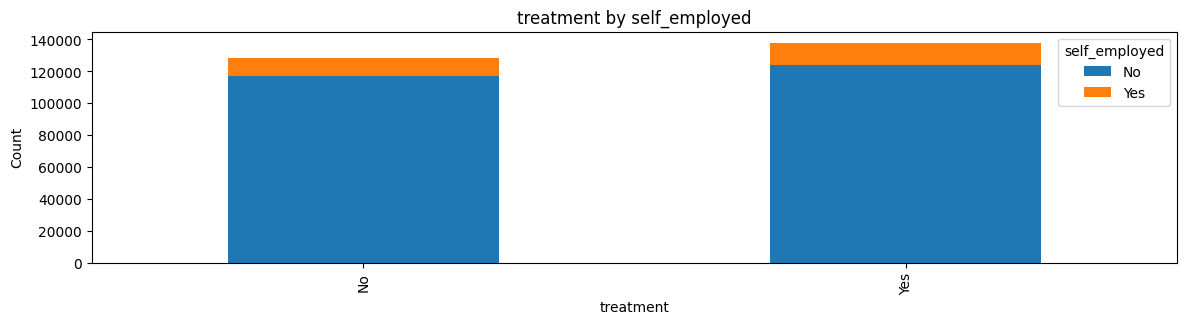

Chi-squared test for self_employed and treatment:
Chi-squared: 125.12092188794114, p-value: 4.788592560195447e-29

Contingency table of treatment and occupation 
 occupation  Business  Corporate  Housewife  Others  Student
treatment                                                  
No             22314      27739      29711   23451    27459
Yes            24285      29029      31895   25665    29970


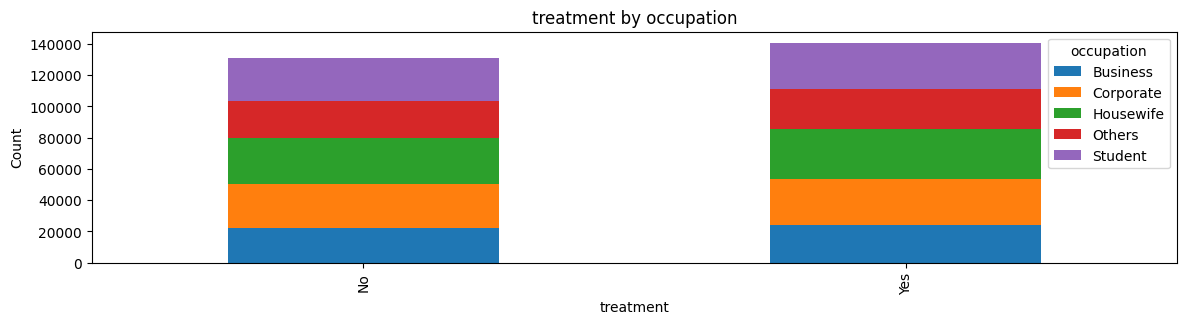

Chi-squared test for occupation and treatment:
Chi-squared: 18.794979811164804, p-value: 0.0008622843375040571

Contingency table of treatment and days_indoors 
 days_indoors  1-14 days  15-30 days  31-60 days  Go out Every day  \
treatment                                                           
No                28653       23969       27135             25991   
Yes               30300       26045       29241             28238   

days_indoors  More than 2 months  
treatment                         
No                         24926  
Yes                        27020  


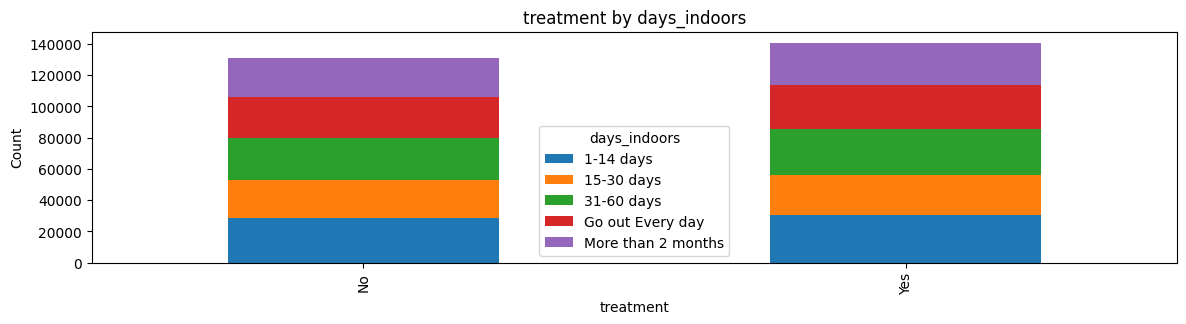

Chi-squared test for days_indoors and treatment:
Chi-squared: 7.455766249094018, p-value: 0.1136757064550174

Contingency table of treatment and growing_stress 
 growing_stress  Maybe     No    Yes
treatment                          
No              45095  41591  43988
Yes             47657  44486  48701


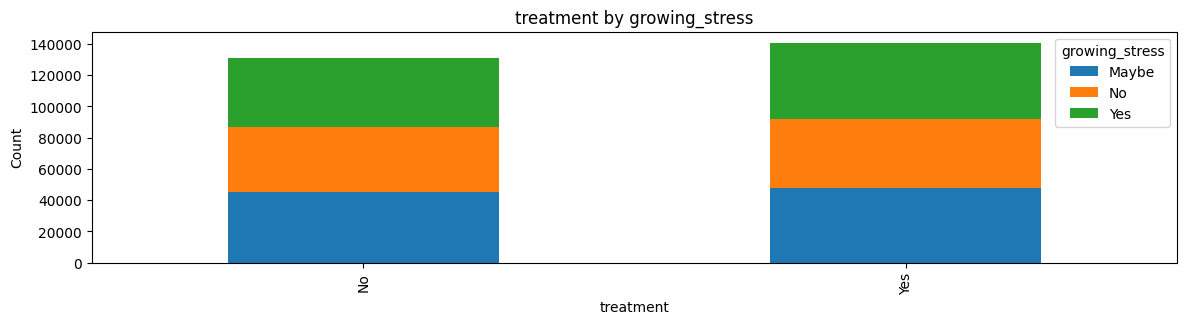

Chi-squared test for growing_stress and treatment:
Chi-squared: 26.887737474028654, p-value: 1.4501134879913062e-06

Contingency table of treatment and changes_habits 
 changes_habits  Maybe     No    Yes
treatment                          
No              42541  39080  49053
Yes             45838  42371  52635


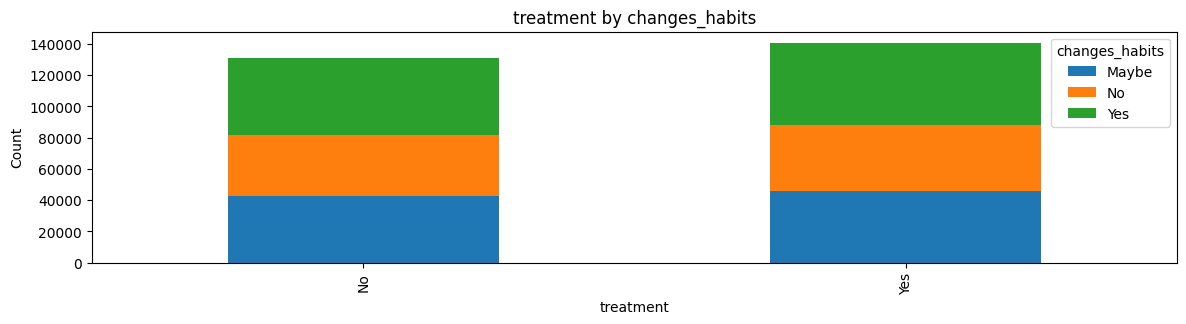

Chi-squared test for changes_habits and treatment:
Chi-squared: 1.2178595515529769, p-value: 0.5439326876190658

Contingency table of treatment and mental_health_history 
 mental_health_history  Maybe     No    Yes
treatment                                 
No                     42268  46743  41663
Yes                    46402  49794  44648


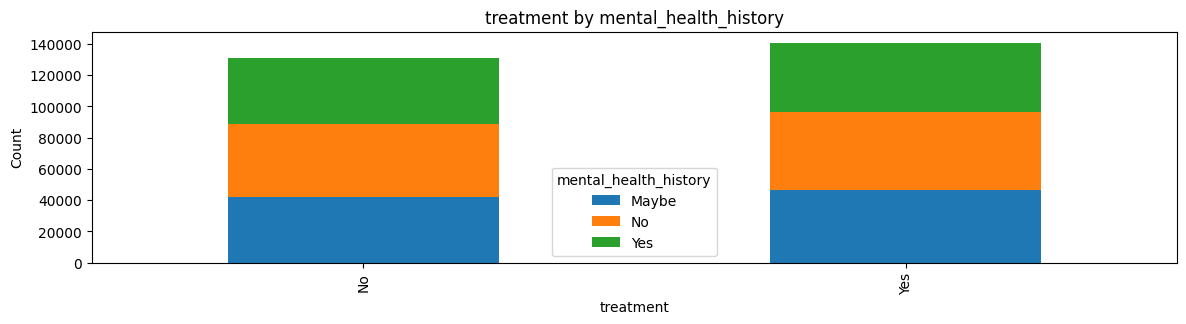

Chi-squared test for mental_health_history and treatment:
Chi-squared: 11.48355351473491, p-value: 0.0032090614833826547

Contingency table of treatment and mood_swings 
 mood_swings   High    Low  Medium
treatment                        
No           40656  44714   45304
Yes          44346  47978   48520


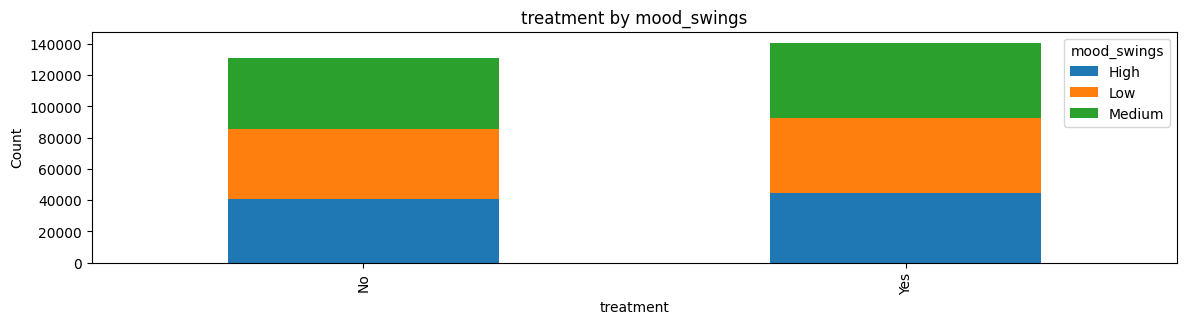

Chi-squared test for mood_swings and treatment:
Chi-squared: 4.434701212879146, p-value: 0.10889723861454834

Contingency table of treatment and coping_struggles 
 coping_struggles     No    Yes
treatment                     
No                69553  61121
Yes               73624  67220


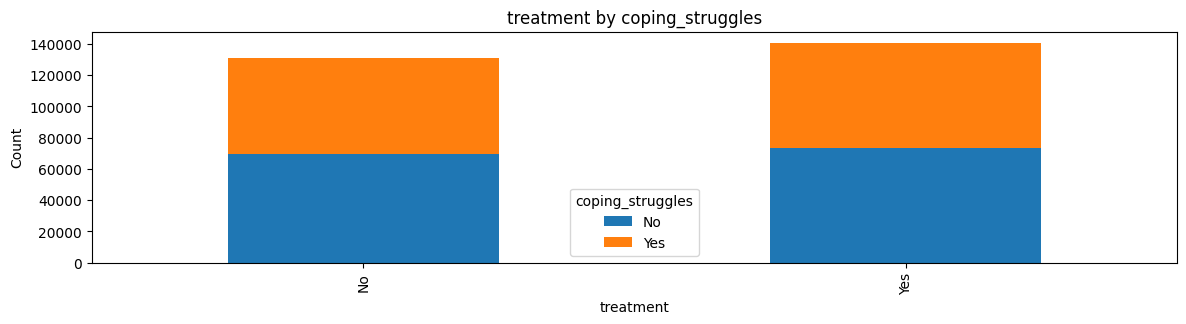

Chi-squared test for coping_struggles and treatment:
Chi-squared: 24.65589066796329, p-value: 6.853494606180042e-07

Contingency table of treatment and work_interest 
 work_interest  Maybe     No    Yes
treatment                         
No             45340  47398  37936
Yes            48601  50875  41368


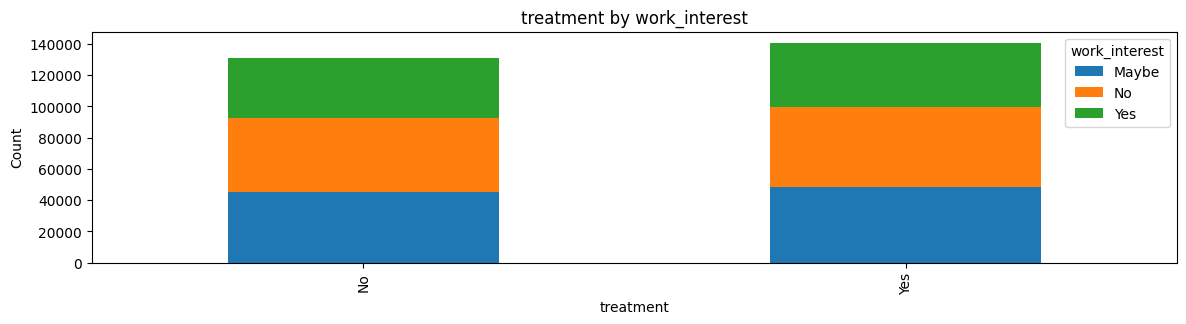

Chi-squared test for work_interest and treatment:
Chi-squared: 3.8218333975521928, p-value: 0.14794470368598667

Contingency table of treatment and social_weakness 
 social_weakness  Maybe     No    Yes
treatment                           
No               46333  43419  40922
Yes              49657  47028  44159


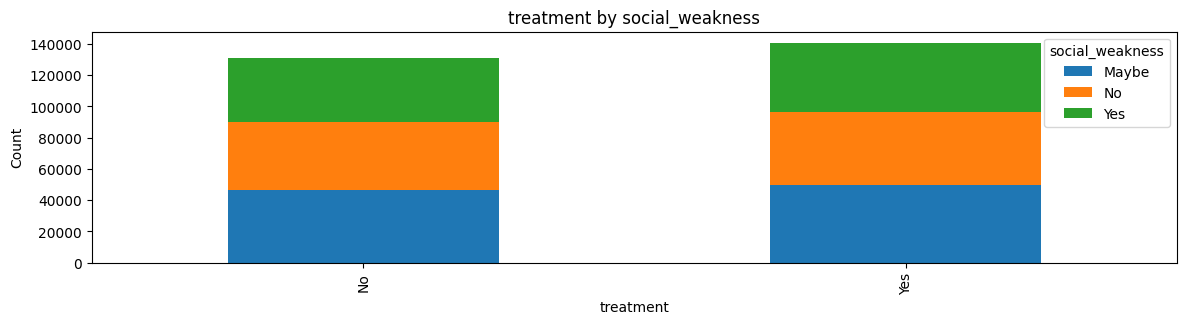

Chi-squared test for social_weakness and treatment:
Chi-squared: 1.33992239041147, p-value: 0.5117284349179005

Contingency table of treatment and mental_health_interview 
 mental_health_interview  Maybe      No   Yes
treatment                                   
No                       27476   99254  3944
Yes                      18984  117960  3900


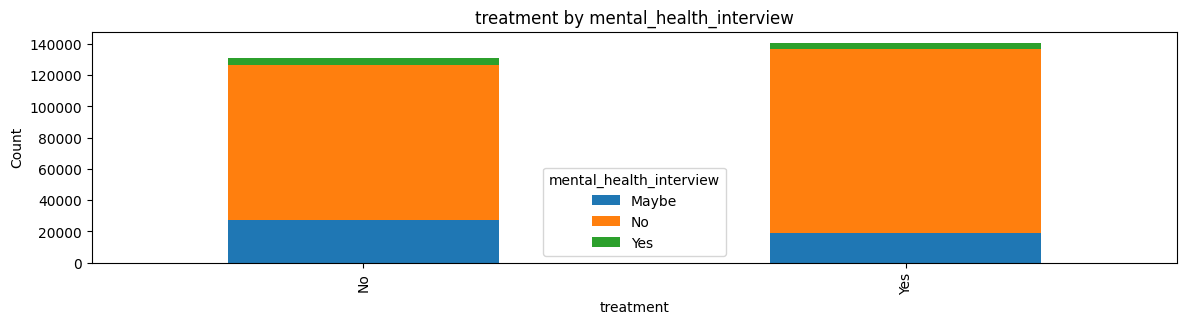

Chi-squared test for mental_health_interview and treatment:
Chi-squared: 2786.323133541314, p-value: 0.0

Contingency table of treatment and care_options 
 care_options     No  Not sure    Yes
treatment                           
No            60978     44384  25312
Yes           45774     29784  65286


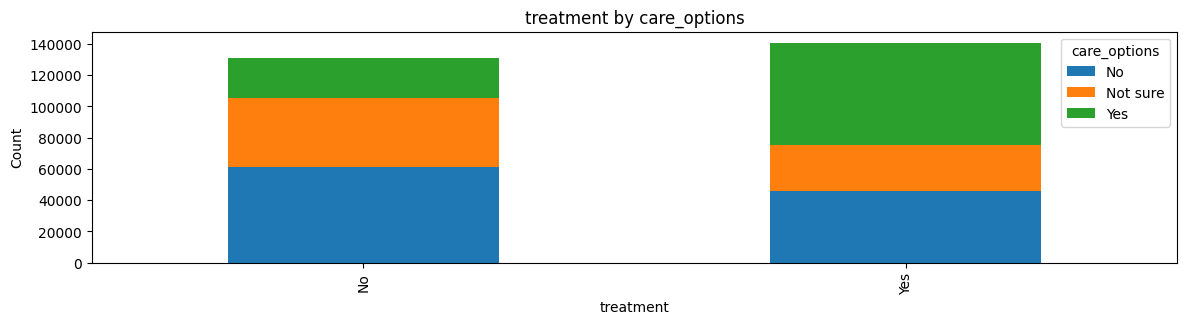

Chi-squared test for care_options and treatment:
Chi-squared: 22327.30240439727, p-value: 0.0

Contingency table of treatment and country 
 country    Australia  Canada  France  Germany  India  Ireland  Netherlands  \
treatment                                                                    
No              2384    8624    2340     2340   1950     2818         3944   
Yes             3642   10102       0     2340    824     2730         1950   

country    Sweden  United Kingdom  United States  
treatment                                         
No           1994           26004          78276  
Yes           824           25400          93032  


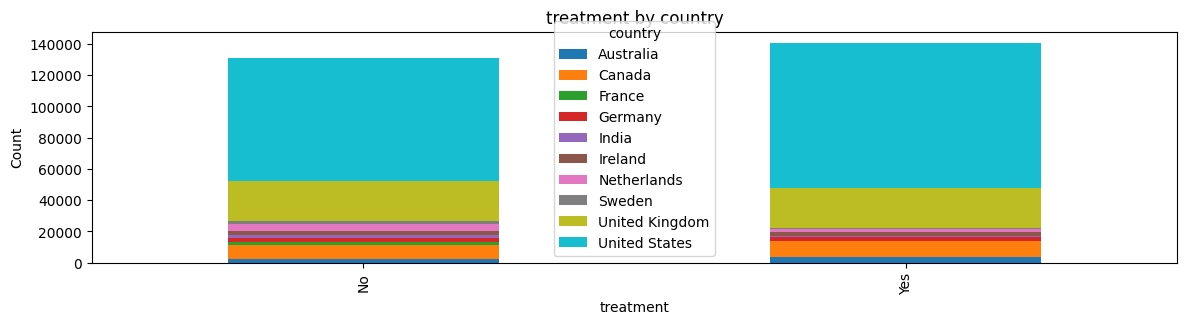

Chi-squared test for country and treatment:
Chi-squared: 5242.656207775554, p-value: 0.0



In [17]:
# Perform the bivariate analysis

# Create the list of categorical variables to analyze
vars_to_analyze = ['gender', 'family_history', 'self_employed', 'occupation',
                'days_indoors', 'growing_stress', 'changes_habits', 'mental_health_history',
                'mood_swings', 'coping_struggles', 'work_interest', 'social_weakness',
                'mental_health_interview', 'care_options', 'country']

# Call the function specifying the 10 most frequent countries
bivariate_analysis(df, 'treatment', vars_to_analyze, top_countries=10)

### Initial conclusions

The univariate and bivariate analyses show a dataset that is well structured for implementing the models.

In addition, regarding the correlations between each categorical variable and the target variable (treatment), the results indicate:

* That factors such as family history, gender, care options, country, and stress are strongly correlated with seeking mental health treatment.

* Variables such as occupation and self-employment are also relevant, but with a weaker association.

* Variables such as days indoors, changes in habits, and interest at work did not show significant associations, suggesting that these factors may not be as influential in the decision to seek treatment.

# 3. Data Treatment

##### Define helper functions

In [18]:
def preprocess_data(df):
    """
    Preprocesses the data by handling missing values in the 'self_employed' column.
    Parameters:
        df: The pandas DataFrame to preprocess.
    Returns:
        Df: The preprocessed DataFrame.
    """
    # Handling missing values
    probs = df['self_employed'].value_counts(normalize = True)
    missing = df['self_employed'].isnull()
    df.loc[missing, 'self_employed'] = np.random.choice(probs.index, size = len(df[missing]), p = probs.values)
    return df

### Impact analysis and treatment of null data

Before starting the clustering analysis, I need to handle the null values.

The only column with null data is *self_employed*, as indicated by the yellow lines in the chart.
- The missing values in the self_employed column are distributed relatively uniformly across the observations, with no specific clustering pattern.

Based on this information and on the project goal, I chose to handle them through proportional imputation.

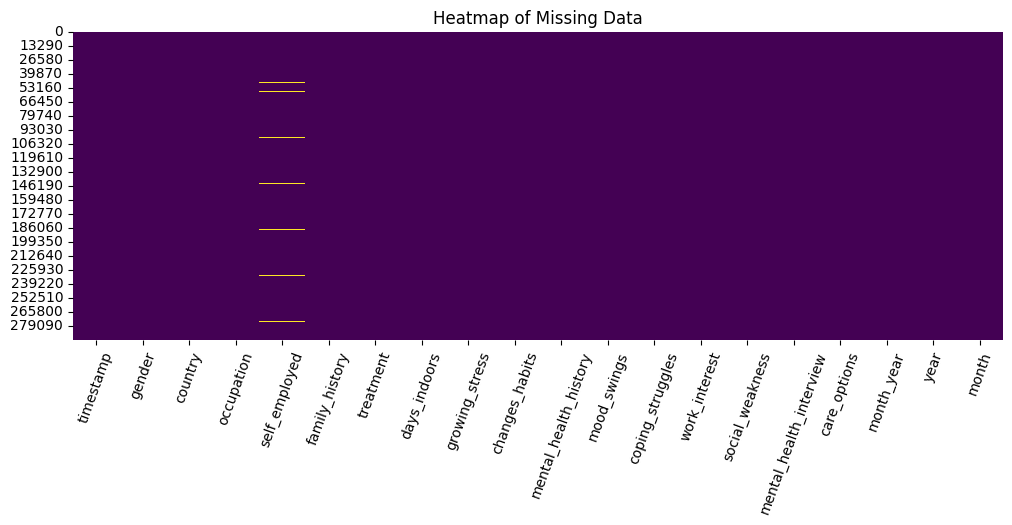

In [19]:
# Heatmap of null data
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Data')
plt.xticks(rotation=70)
plt.show() 

In [20]:
# Handle null values in 'self_employed' - proportional imputation
preprocess_data(df)

# Check the missing data again
print(df.isnull().sum())

timestamp                  0
gender                     0
country                    0
occupation                 0
self_employed              0
family_history             0
treatment                  0
days_indoors               0
growing_stress             0
changes_habits             0
mental_health_history      0
mood_swings                0
coping_struggles           0
work_interest              0
social_weakness            0
mental_health_interview    0
care_options               0
month_year                 0
year                       0
month                      0
dtype: int64


In [21]:
# Drop columns that will not be used
df = df.drop(['timestamp', 'month_year', 'year', 'month'], axis=1)

# 4. Data Preparation for Supervised Modeling

Since the dataset has only — and many — categorical variables that relate to one another in complex ways (as shown by the EDA), and its size is relatively large, I opted for an **ensemble** model. These models handle the complexity and volume of the data better and offer additional advantages, such as the ability to assess feature importance.

**Define helper functions**

In [22]:
def encode_labels(y):
    """
    Encodes target labels into numeric form.
    Parameters:
        y (Series): The target labels.
    Returns:
        tuple: A tuple containing the encoded labels and the LabelEncoder instance.
    """
    label_encoder = LabelEncoder()
    return label_encoder.fit_transform(y), label_encoder

def setup_pipeline(X_train, categorical_feats, optimized_params=None):
    """
    Sets up a machine learning pipeline with preprocessing and a classifier.
    Parameters:
        X_train (DataFrame): The training data.
        categorical_feats (list): List of categorical features to encode.
        optimized_params (dict, optional): Parameters for the XGBClassifier.
    Returns:
        Pipeline: The constructed pipeline.
    """
    binary_encoder = ce.BinaryEncoder(cols=categorical_feats)
    preprocessor = ColumnTransformer(transformers=[('cat', binary_encoder, categorical_feats)])
    if optimized_params is None:
        optimized_params = {}
    classifier = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', **optimized_params)
    return Pipeline(steps=[('preprocessor', preprocessor), ('classifier', classifier)])


def evaluate_model(model, X_train, y_train, X_test, y_test, label_encoder):
    """
    Evaluates the performance of a machine learning model using the training and test datasets.
    The function prints a classification report that includes precision, recall, and F1-score for each class.
    Additionally, it displays a confusion matrix to provide a visual representation of the model's performance
    in terms of correctly and incorrectly classified instances.
    Parameters:
        model (Pipeline): The trained machine learning model pipeline, which includes preprocessing steps and the classifier.
        X_train (DataFrame): The training dataset features used for making predictions.
        y_train (Series): The actual labels of the training dataset, used to compare against the predictions.
        X_test (DataFrame): The test dataset features used for making predictions.
        y_test (Series): The actual labels of the test dataset, used to compare against the predictions.
        label_encoder (LabelEncoder): An instance of LabelEncoder that was used to encode the target labels. This is used
                                      to transform labels back to their original encoding for a more interpretable output.
    Returns:
        None: This function does not return any value. It outputs the classification report and confusion matrix plot directly.
    """
    try:
        # Predictions for the test set
        y_pred_test = model.predict(X_test)
        y_pred_test_proba = model.predict_proba(X_test)[:, 1]

        # Evaluate model on the test set
        test_score = model.score(X_test, y_test)
        auc_roc_test = roc_auc_score(y_test, y_pred_test_proba)
        logging.info(f'Test Accuracy: {test_score}')
        logging.info(f'Test AUC-ROC: {auc_roc_test}')
        print(f'Test set score: {test_score}')

        # Predictions for the training set
        y_pred_train = model.predict(X_train)
        y_pred_train_proba = model.predict_proba(X_train)[:, 1]

        # Decode labels
        y_train_decoded = label_encoder.inverse_transform(y_train)
        y_pred_train_decoded = label_encoder.inverse_transform(y_pred_train)
        y_test_decoded = label_encoder.inverse_transform(y_test)
        y_pred_test_decoded = label_encoder.inverse_transform(y_pred_test)

        # Classification report for the training set
        print('TRAINING')
        print(classification_report(y_train_decoded, y_pred_train_decoded))

        # Confusion matrix for the training set
        disp = ConfusionMatrixDisplay.from_predictions(y_train_decoded, y_pred_train_decoded)
        disp.figure_.set_size_inches(6, 2)
        plt.show()

        # Classification report for the test set
        print('TEST')
        print(classification_report(y_test_decoded, y_pred_test_decoded))

        # Confusion matrix for the test set
        disp = ConfusionMatrixDisplay.from_predictions(y_test_decoded, y_pred_test_decoded)
        disp.figure_.set_size_inches(6, 2)
        plt.show()

    except Exception as e:
        logging.error('Error during model prediction or evaluation', exc_info=True)

def plot_feature_importance(model, X_train):
    """
    Plots the feature importance of a trained XGBoost model.
    Parameters:
        model (Pipeline): The trained machine learning model pipeline, which includes preprocessing steps and the classifier.
        X_train (DataFrame): The training dataset features used for making predictions.
    Returns:
        None: This function does not return any value. It displays the feature importance plot directly.
    """
    # Get the list of column names
    feature_names = X_train.columns.tolist()
    # Create the mapping from labels to column names
    feature_map = {f'f{i}': feature for i, feature in enumerate(feature_names)}

    # Get the feature importances
    model = model.named_steps['classifier']
    importance = model.get_booster().get_score(importance_type='weight')

    # Map the labels to the column names
    importance_mapped = {feature_map[k]: v for k, v in importance.items() if k in feature_map}

    # Plot the feature importances with the original variable names
    fig, ax = plt.subplots(figsize=(10, 5))
    xgb.plot_importance(model, max_num_features = 10, height = 0.5, color='orange', show_values = True, ax = ax)
    ax.set_title('Top 10 Most Important Variables', fontsize = 14)
    ax.set_ylabel('Variables', fontsize = 12)
    ax.set_xlabel('F score', fontsize = 12)
    ax.tick_params(axis='y', labelsize = 10)
    ax.tick_params(axis='x', labelsize = 10)
    # Replace the y-axis labels with the original column names
    y_labels = [feature_map[f'f{i}'] for i in range(10) if f'f{i}' in feature_map]
    ax.set_yticklabels(y_labels)
    plt.show()

In [23]:
# Separate target (y) and explanatory (X) variables, encoding labels in y
y, label_encoder = encode_labels(df['treatment'])
X = df.drop('treatment', axis=1)

# Confirm
y

array([1, 1, 1, ..., 0, 1, 1])

In [24]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = SEED)

# Check
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233891 entries, 218898 to 4581
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   gender                   233891 non-null  object
 1   country                  233891 non-null  object
 2   occupation               233891 non-null  object
 3   self_employed            233891 non-null  object
 4   family_history           233891 non-null  object
 5   days_indoors             233891 non-null  object
 6   growing_stress           233891 non-null  object
 7   changes_habits           233891 non-null  object
 8   mental_health_history    233891 non-null  object
 9   mood_swings              233891 non-null  object
 10  coping_struggles         233891 non-null  object
 11  work_interest            233891 non-null  object
 12  social_weakness          233891 non-null  object
 13  mental_health_interview  233891 non-null  object
 14  care_options          

# 5. Supervised Modeling

## 5.1. XGBoost Model 1

In [25]:
# Preprocessing
df = preprocess_data(df)

# Set up pipeline
categorical_feats = X_train.select_dtypes(include=['object']).columns.tolist()
xgb_pipeline = setup_pipeline(X_train, categorical_feats)

# Train the model
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  BinaryEncoder(cols=['gender',
                                                                      'country',
                                                                      'occupation',
                                                                      'self_employed',
                                                                      'family_history',
                                                                      'days_indoors',
                                                                      'growing_stress',
                                                                      'changes_habits',
                                                                      'mental_health_history',
                                                                      'mood_swings',
                                                                      'coping_struggles',
                                                                      'work_interest',
                                                                      'social_weakness',
                                                                      'mental_health_interview',
                                                                      'care_options']),
                                                  ['gender', '...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

2026-06-22 09:46:44,235 - INFO - Test Accuracy: 0.7734680963863664
2026-06-22 09:46:44,236 - INFO - Test AUC-ROC: 0.8653928115896048


Test set score: 0.7734680963863664
TRAINING
              precision    recall  f1-score   support

          No       0.82      0.72      0.76    115806
         Yes       0.75      0.84      0.80    118085

    accuracy                           0.78    233891
   macro avg       0.79      0.78      0.78    233891
weighted avg       0.79      0.78      0.78    233891



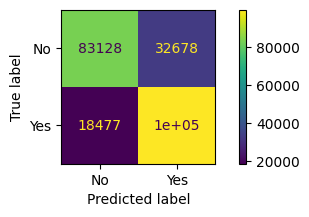

TEST
              precision    recall  f1-score   support

          No       0.81      0.71      0.76     28952
         Yes       0.75      0.83      0.79     29521

    accuracy                           0.77     58473
   macro avg       0.78      0.77      0.77     58473
weighted avg       0.78      0.77      0.77     58473



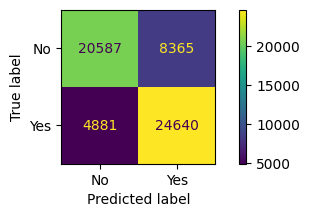

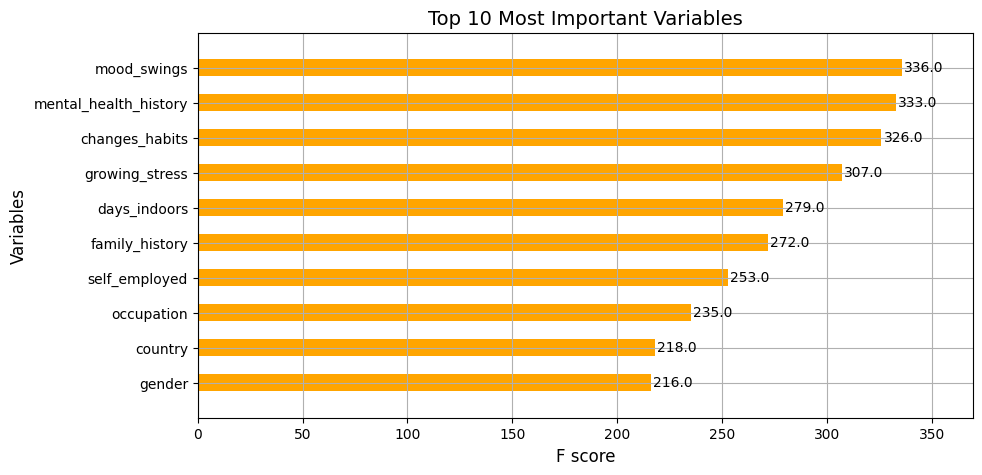

In [26]:
# Evaluate the model using the test set
evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test, label_encoder)

# Analyze the model's feature importance
plot_feature_importance(xgb_pipeline, X_train)

### Interpretation

* Model 1 performs similarly on training and test, a sign that no significant overfitting is occurring.
* The model has relatively high **precision** for both classes, but is slightly better at predicting the 'No' class.
* **Recall** is higher for the 'Yes' class in both sets, indicating that it is more effective at identifying all positive cases for 'Yes' than for 'No'.
* The **F1-Score** values are fairly balanced, suggesting a good balance between precision and recall for both classes.

**Conclusions and next steps**
* Model 1 seems to slightly favor the 'Yes' class in terms of recall. Since a better balance between precision and recall is important, I can consider adjusting the classification threshold or exploring class-balancing techniques.
* Experimenting with XGBoost parameter adjustments or other preprocessing techniques may also help improve precision for the 'No' class and recall for the 'Yes' class.
* For a more robust evaluation, I can also consider implementing cross-validation to ensure the results are consistent across different subsets of the dataset.

# 6. Optimization and Tuning of the Supervised Model

## 6.1. Error analysis

In [27]:
# Define y_pred_test
y_pred_test = xgb_pipeline.predict(X_test)

# Analyze specific false-positive and false-negative cases
false_positives = X_test[(y_pred_test == 1) & (y_test == 0)]
false_negatives = X_test[(y_pred_test == 0) & (y_test == 1)]

# Display
print(f'False Positives: {false_positives}')
print(f'False Negatives: {false_negatives}')

False Positives:        gender         country occupation self_employed family_history  \
181639   Male  United Kingdom    Student            No            Yes   
58723    Male   United States    Student            No             No   
81628    Male   United States     Others            No            Yes   
91195    Male   United States     Others            No             No   
203186   Male   United States   Business            No            Yes   
...       ...             ...        ...           ...            ...   
242608   Male   United States   Business            No             No   
227534   Male   United States   Business            No             No   
149833   Male          Canada  Corporate            No             No   
90004    Male  United Kingdom  Housewife            No            Yes   
152205   Male  United Kingdom     Others           Yes             No   

              days_indoors growing_stress changes_habits  \
181639           1-14 days          Maybe     

In a real-world setting, I could dig deeper into the FP and FN entries, understand whether FPs or FNs appear more frequently in specific features, etc.

- For this project, I will only compare the totals of FNs and FPs.

## 6.2. Test of Model 1 using OneHotEncoder and class balancing (SMOTE)

In [28]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Preprocessing of the other variables
# Identify categorical columns
categorical_feats = X_train.select_dtypes(include=['object']).columns.tolist()

# Create the OneHotEncoder
one_hot_encoder = OneHotEncoder(handle_unknown='ignore')

# Create a transformer for the categorical variables using the OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', one_hot_encoder, categorical_feats)
    ])

# Create the SMOTE object
smote = SMOTE(random_state=SEED)

# Create a pipeline for the XGBoost model with SMOTE
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
])

# Train the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country',
                                                   'occupation',
                                                   'self_employed',
                                                   'family_history',
                                                   'days_indoors',
                                                   'growing_stress',
                                                   'changes_habits',
                                                   'mental_health_history',
                                                   'mood_swings',
                                                   'coping_struggles',
                                                   'work_interest',
                                                   'social_weakness',
                                                   'mental_health_interview',
                                                   'care_op...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

2026-06-22 09:53:49,899 - INFO - Test Accuracy: 0.7768542746224754
2026-06-22 09:53:49,901 - INFO - Test AUC-ROC: 0.8668734283375267


Test set score: 0.7768542746224754
TRAINING
              precision    recall  f1-score   support

          No       0.81      0.72      0.76    115863
         Yes       0.75      0.84      0.79    118028

    accuracy                           0.78    233891
   macro avg       0.78      0.78      0.78    233891
weighted avg       0.78      0.78      0.78    233891



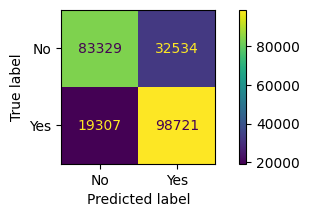

TEST
              precision    recall  f1-score   support

          No       0.81      0.72      0.76     28895
         Yes       0.75      0.83      0.79     29578

    accuracy                           0.78     58473
   macro avg       0.78      0.78      0.78     58473
weighted avg       0.78      0.78      0.78     58473



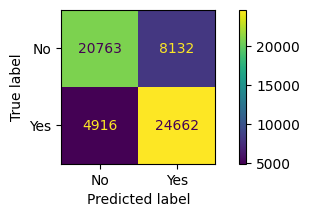

In [29]:
# Evaluate the model using the test set
evaluate_model(model_pipeline, X_train, y_train, X_test, y_test, label_encoder)


Using OneHotEncoder with SMOTE produced results very close to the BinaryEncoder approach — accuracy and AUC-ROC differed only marginally. Since the gain was negligible, I chose to proceed with the simpler BinaryEncoder approach.

## 6.3. Adjust the classification threshold

To improve the balance between precision and recall for the classes.

In [30]:
# Get probabilities for the positive class
prob_pos = xgb_pipeline.predict_proba(X_test)[:, 1]

# Try different thresholds and evaluate the impact
thresholds = [0.1, 0.2, 0.3, 0.5, 0.7]
for threshold in thresholds:
    y_pred_custom = (prob_pos >= threshold).astype(int)
    print(f'Threshold: {threshold}')
    print(classification_report(y_test, y_pred_custom))

Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      0.32      0.48     28895
           1       0.60      1.00      0.75     29578

    accuracy                           0.66     58473
   macro avg       0.80      0.66      0.62     58473
weighted avg       0.80      0.66      0.62     58473

Threshold: 0.2
              precision    recall  f1-score   support

           0       0.98      0.35      0.52     28895
           1       0.61      0.99      0.76     29578

    accuracy                           0.68     58473
   macro avg       0.80      0.67      0.64     58473
weighted avg       0.80      0.68      0.64     58473

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     28895
           1       0.69      0.92      0.79     29578

    accuracy                           0.75     58473
   macro avg       0.78      0.75      0.74     58473
weighted avg       0.78      

A threshold of 0.5 seems to be the most balanced, since it offers a good combination of precision and recall for both classes. This threshold maximizes the F1-score.

## 6.4. Tune the model's hyperparameters

In [31]:
"""# Define the parameter space
param_grid = {
    'classifier__n_estimators': [100, 300],
    'classifier__max_depth': [4, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__gamma': [0, 0.2]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator = model_pipeline,
    param_grid = param_grid,
    scoring='accuracy',
    cv = 3,
    verbose = 2
)

# Train using GridSearchCV
grid_search.fit(X_train, y_train)

# Display best parameters and performance
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_}')

# Evaluate on the test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)

print(f'Test set accuracy: {test_score}')"""

"# Define the parameter space\nparam_grid = {\n    'classifier__n_estimators': [100, 300],\n    'classifier__max_depth': [4, 7],\n    'classifier__learning_rate': [0.01, 0.1],\n    'classifier__gamma': [0, 0.2]\n}\n\n# Set up GridSearchCV\ngrid_search = GridSearchCV(\n    estimator = model_pipeline,\n    param_grid = param_grid,\n    scoring='accuracy',\n    cv = 3,\n    verbose = 2\n)\n\n# Train using GridSearchCV\ngrid_search.fit(X_train, y_train)\n\n# Display best parameters and performance\nprint(f'Best parameters: {grid_search.best_params_}')\nprint(f'Best score: {grid_search.best_score_}')\n\n# Evaluate on the test set\nbest_model = grid_search.best_estimator_\ntest_score = best_model.score(X_test, y_test)\n\nprint(f'Test set accuracy: {test_score}')"

The grid search was run separately due to its long runtime; the results are shown in the images below.

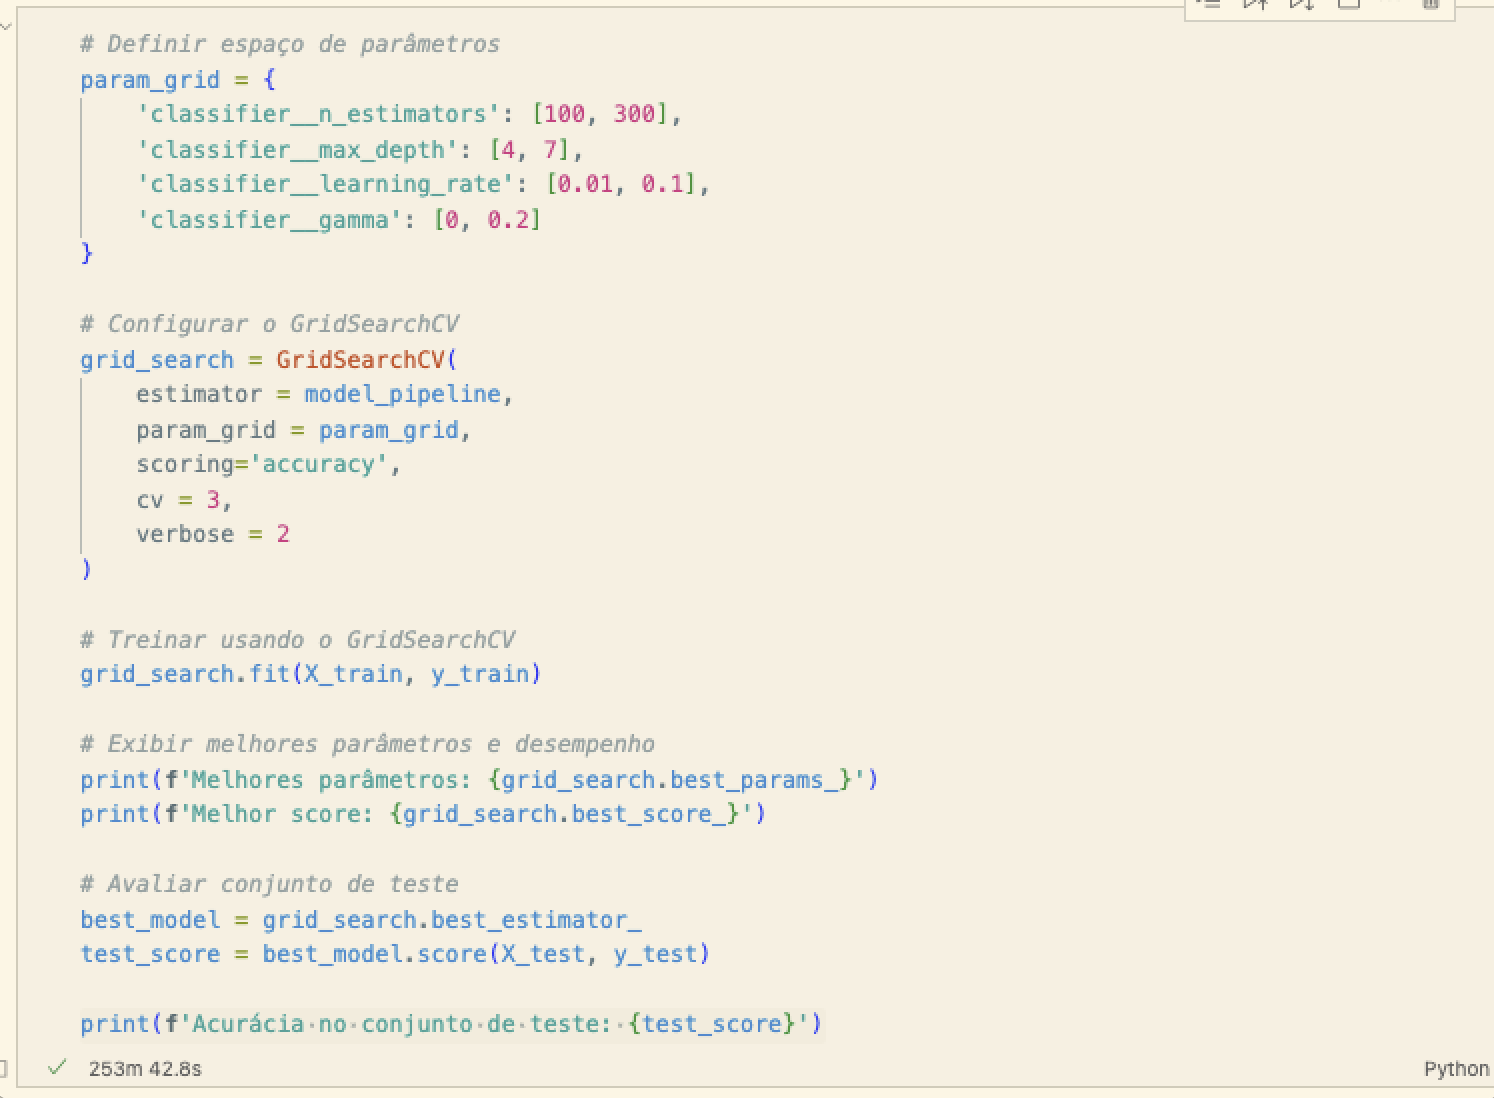
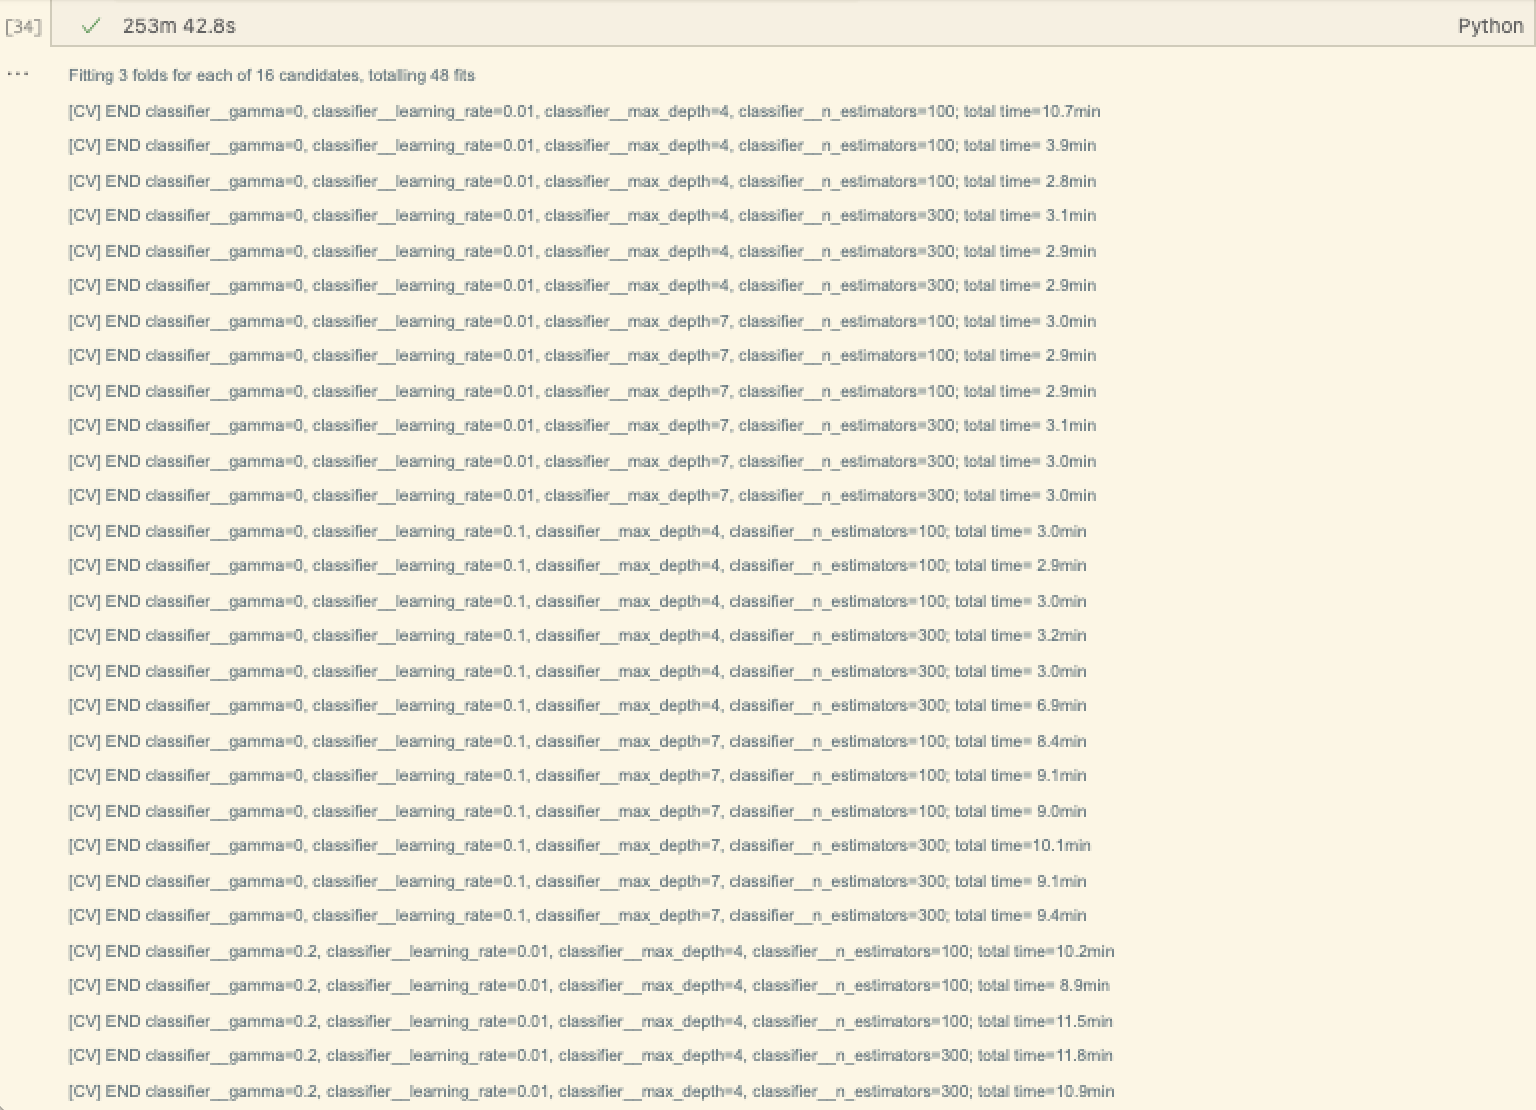
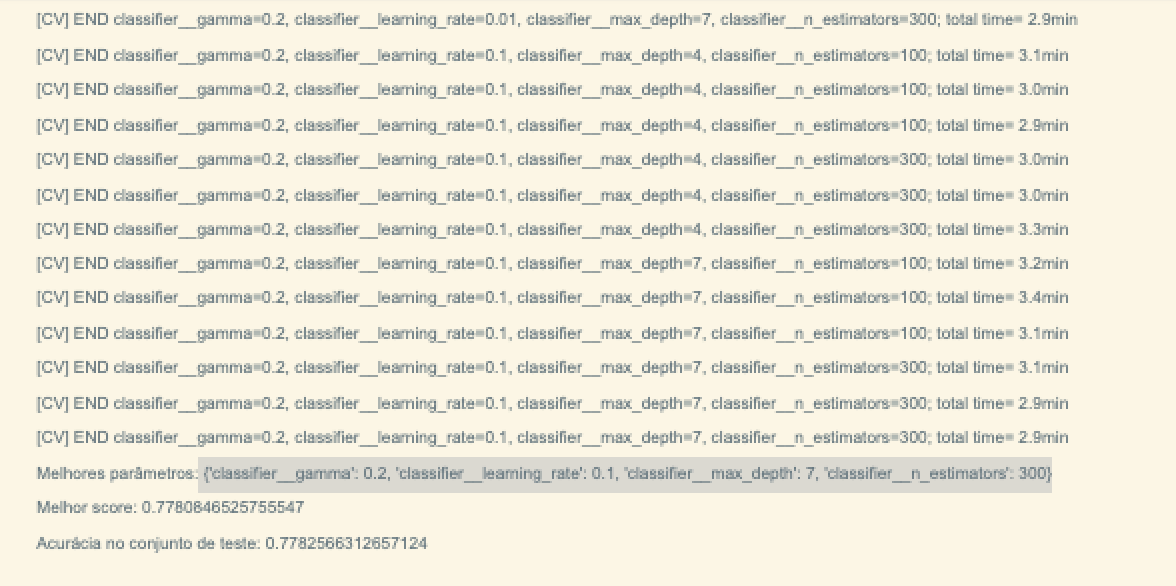

## 6.5. XGBoost Model 2

2026-06-22 09:54:01,679 - INFO - Test Accuracy: 0.7775041472132437
2026-06-22 09:54:01,681 - INFO - Test AUC-ROC: 0.8697616524939715


Test set score: 0.7775041472132437
TRAINING
              precision    recall  f1-score   support

          No       0.82      0.72      0.76    115863
         Yes       0.75      0.84      0.79    118028

    accuracy                           0.78    233891
   macro avg       0.78      0.78      0.78    233891
weighted avg       0.78      0.78      0.78    233891



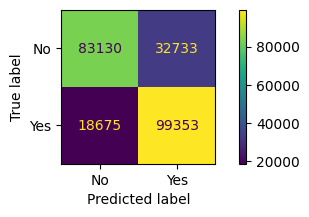

TEST
              precision    recall  f1-score   support

          No       0.81      0.72      0.76     28895
         Yes       0.75      0.84      0.79     29578

    accuracy                           0.78     58473
   macro avg       0.78      0.78      0.78     58473
weighted avg       0.78      0.78      0.78     58473



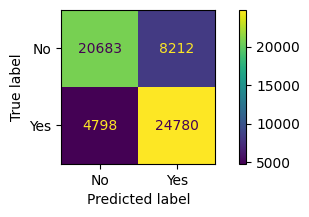

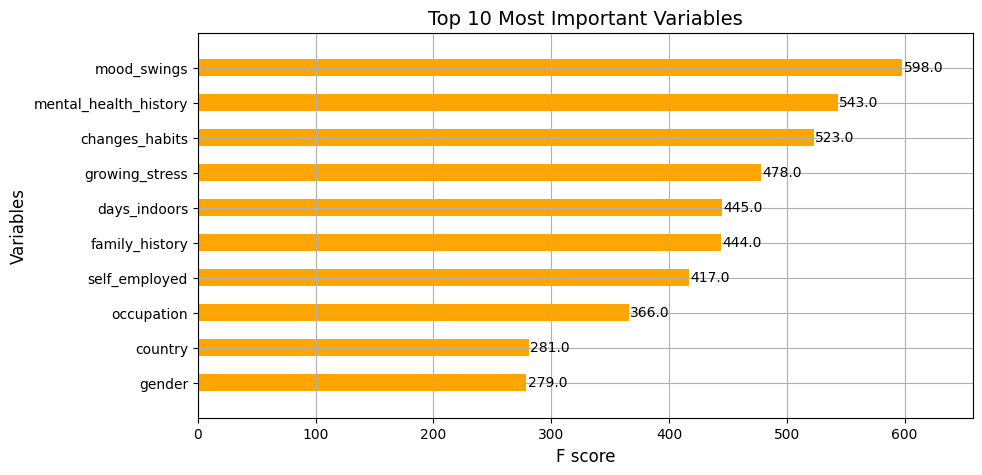

In [32]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Set the optimized parameters for the XGBoost model
optimized_params = {
    'gamma': 0.2,
    'learning_rate': 0.1,
    'max_depth': 7,
    'n_estimators': 300
}

# Call setup_pipeline to build the pipeline
xgb_pipeline = setup_pipeline(X_train, categorical_feats, optimized_params)

# Train the model
xgb_pipeline.fit(X_train, y_train)

#----------------------------------------
# Evaluate model

# Evaluate the model using the test set
evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test, label_encoder)

# Analyze the model's feature importance
plot_feature_importance(xgb_pipeline, X_train)

# 7. Conclusions and notes on the XGBoost supervised model

XGBoost appears to be effective for the task, with consistent performance on both the training and test sets, indicating no significant overfitting.

**Improvement notes**
* Adjustments to the model parameters and the classification threshold could further improve precision and recall, especially for imbalanced classes.
* Exploring additional class-balancing and data-preprocessing techniques could be beneficial.
* Testing other models seems to be the most effective next step.

Comparing the two trained XGBoost models (before and after parameter adjustments and threshold definition), I note that both show very similar performance, with slight differences in the evaluation metrics:

**Accuracy**
* Both models reached a test accuracy of around 0.77–0.78.
* Model 2 was marginally ahead, which suggests it may generalize slightly better — although the difference is small.

**AUC-ROC**
* Both models reached a test AUC-ROC of around 0.87.
* Model 2 was again marginally ahead, suggesting a slightly better ability to discriminate between the positive and negative classes.

**Classification metrics (Precision, Recall, F1-Score)**
* Both models show very similar metrics on both training and test, with small variations in *precision, recall, and F1-score* for the "No" and "Yes" classes. The differences are minimal and both models show a similar balance between *precision and recall*.

* Precision: similar for the "No" and "Yes" classes in both models.
* Recall: also very close between the two models for both classes.
* F1-Score: the F1-scores are comparable as well, reflecting a good balance between precision and recall.

Model 2 shows a slight improvement in accuracy and AUC-ROC compared with Model 1. The differences are quite small, indicating that both are comparably effective.

Specifically on the **comparison of the most important variables**:

| Rank | Variable | F Score (Model 1) | F Score (Model 2) |
|------|------------------------|--------------------|--------------------|
| 1 | mood_swings | 314.0 | 596.0 |
| 2 | mental_health_history | 313.0 | 578.0 |
| 3 | changes_habits | 286.0 | 554.0 |
| 4 | growing_stress | 275.0 | 538.0 |
| 5 | days_indoors | 270.0 | 447.0 |
| 6 | family_history | 270.0 | 443.0 |
| 7 | self_employed | 266.0 | 434.0 |
| 8 | occupation | 260.0 | 389.0 |
| 9 | country | 249.0 | 286.0 |
| 10 | gender | 219.0 | 280.0 |

* The 10 most important variables are identical in both models, as is the order in which they appear; the same variables are therefore considered crucial in both models.

* In the Model 2 chart, the F scores are significantly higher than in Model 1, which may indicate that Model 2 assigns greater importance to the variables compared with Model 1.

* Among the 10 variables, *mood_swings* shows the largest F-score difference, and *mental_health_history* also shows a significant difference.

* Despite the differences in absolute values, the consistency in the order of the most important variables suggests that both models are capturing similar patterns in the data.

* The feature-importance analysis in both models indicates that variables related to mental health, behavioral changes, stress, and family history are the most important for the model.

* The variables mood_swings, mental_health_history, changes_habits, and growing_stress have a significantly greater impact in Model 2, as indicated by the higher scores.

* Model 2 assigns significantly greater importance to the variables, which may indicate a better ability to discriminate between the classes.

* The differences in F scores may be attributable to variations in hyperparameters, but the consistency in the order of the most important variables reinforces the relevance of these variables in predicting mental health conditions.

# 8. Data Preparation for Unsupervised Modeling

In [33]:
# Load DF and handle null values and the 'timestamp' variable

# Make a copy of df
df_b = df_original.copy()

# Rename and reorganize columns
df_b = clean_column_names(df_b)

# Transform the 'timestamp' column
df_b = transform_timestamp(df_b, 'timestamp')
# Drop the 'timestamp' column
df_b = df_b.drop(['timestamp'], axis = 1)

# Handle null values in 'self_employed' - proportional imputation
preprocess_data(df_b)

df_b.head()

,gender,country,occupation,self_employed,family_history,treatment,days_indoors,growing_stress,changes_habits,mental_health_history,mood_swings,coping_struggles,work_interest,social_weakness,mental_health_interview,care_options,month_year,year
0,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure,2014-08,2014
1,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No,2014-08,2014
2,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014-08,2014
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes,2014-08,2014
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes,2014-08,2014


# 9. Unsupervised Modeling

In [34]:
def perform_kmeans_clustering(df, n_clusters=3, random_state=None, use_sparse_data=False):
    """
    Performs K-means clustering on the given DataFrame and plots the clusters.
    Allows for handling sparse data by adjusting the StandardScaler.
    Parameters:
        df (pd.DataFrame): DataFrame to cluster.
        n_clusters (int): Number of clusters to form.
        random_state (int): Random state for reproducibility.
        use_sparse_data (bool): Whether to use settings appropriate for sparse data.
    Returns:
        tuple: A tuple containing the modified DataFrame and the pipeline.
    """
    # Identify numerical and categorical variables
    categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Create OneHotEncoder and StandardScaler
    onehot_encoder = OneHotEncoder()
    scaler = StandardScaler(with_mean=not use_sparse_data)

    # Create a ColumnTransformer to apply the transformations
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, numerical_features),
            ('cat', Pipeline([
                ('onehot', onehot_encoder),
                ('scaler', scaler)
            ]), categorical_features)
        ])

    # Create and configure the pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('kmeans', KMeans(n_clusters=n_clusters, random_state=random_state))
    ])

    # Fit the pipeline
    pipeline.fit(df)

    # Add the cluster labels to the DF
    df['cluster'] = pipeline.named_steps['kmeans'].labels_

    # Visualize the clusters
    svd = TruncatedSVD(n_components=2)
    df_transformed = svd.fit_transform(pipeline.named_steps['preprocessor'].transform(df).toarray())
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df_transformed[:, 0], y=df_transformed[:, 1], hue=df['cluster'], palette='viridis')
    plt.title('Clusters formed by K-means')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

    return df, pipeline

def evaluate_clustering_model(pipeline, df, max_clusters=10):
    """
    Evaluates the clustering model using silhouette score, Davies-Bouldin score, and the elbow method.
    Parameters:
        pipeline (Pipeline): Fitted sklearn pipeline that includes preprocessing and clustering.
        df (pd.DataFrame): DataFrame that was used in the clustering model.
        max_clusters (int): Maximum number of clusters to consider for the elbow method.
    Returns:
        None: This function prints evaluation metrics and plots the elbow method graph.
    """
    # Transform the data using the preprocessor in the pipeline
    X_transformed = pipeline.named_steps['preprocessor'].transform(df).toarray()
    
    # Compute the Silhouette and Davies-Bouldin scores
    silhouette_avg = silhouette_score(X_transformed, df['cluster'])
    davies_bouldin_avg = davies_bouldin_score(X_transformed, df['cluster'])
    print(f'Silhouette Coefficient: {silhouette_avg}')
    print(f'Davies-Bouldin Index: {davies_bouldin_avg}')
    
    # Elbow method to determine the ideal number of clusters
    inertia = []
    K = range(1, max_clusters + 1)
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=pipeline.named_steps['kmeans'].random_state)
        kmeans.fit(X_transformed)
        inertia.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 6))
    plt.plot(K, inertia, 'bx-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.show()

## 9.1. K-Means

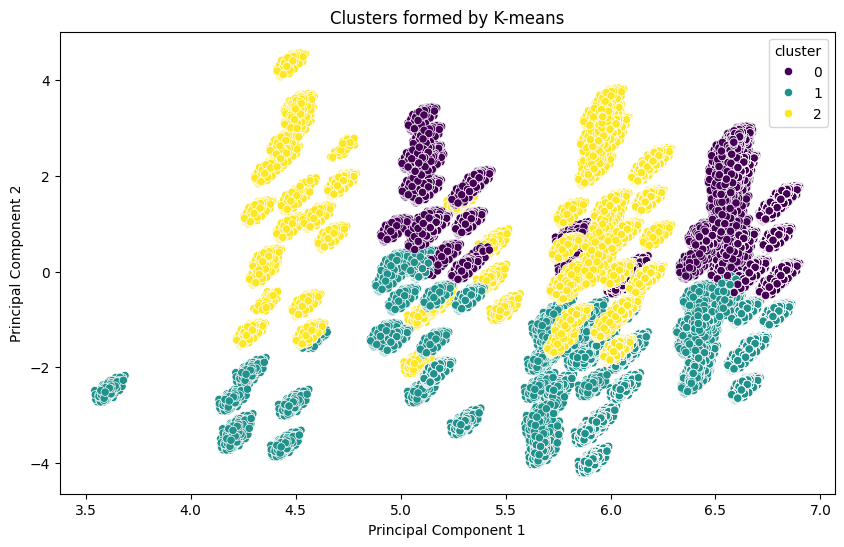

Silhouette Coefficient: 0.02208374009027131
Davies-Bouldin Index: 4.669464746848973


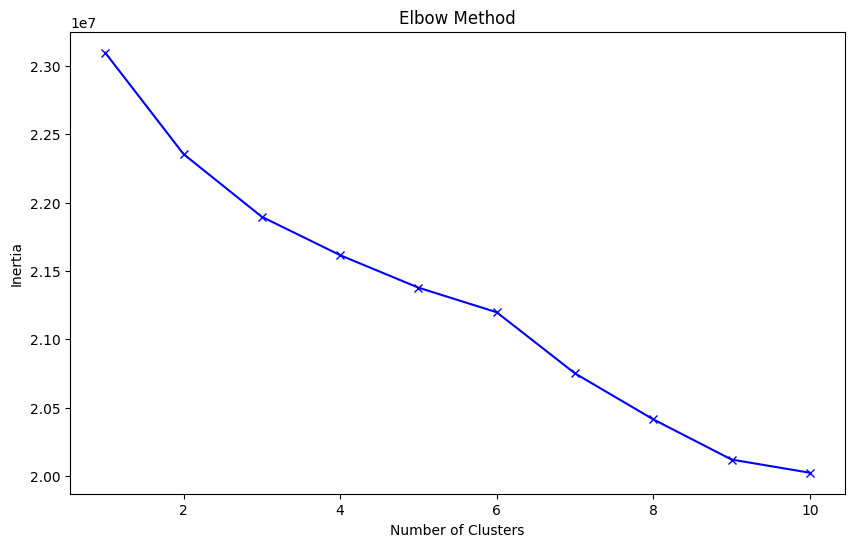

In [35]:





# Run K-Means with n_clusters = 3
df_b, pipeline = perform_kmeans_clustering(df_b, n_clusters = 3, random_state = SEED, use_sparse_data = True)

# Evaluate the model
evaluate_clustering_model(pipeline, df_b, max_clusters = 10)

The Silhouette Coefficient and the Davies-Bouldin Index indicate that the quality of the clusters formed by K-Means may not be ideal for the current data:

1. Silhouette Coefficient (around 0.02)
    * A value very close to 0, suggesting that the clusters overlap substantially and that points within a cluster are not significantly closer to each other than to points in other clusters.

2. Davies-Bouldin Index (above 4)
    * The high value indicates that the average similarity between each cluster and its nearest cluster is high; thus, the clusters are less well defined and less distinct.

Because of this and of the Elbow Method chart, I decided to test K-Means again, excluding some features and using a new number of clusters (7).

# 10. Optimization and Tuning of K-Means

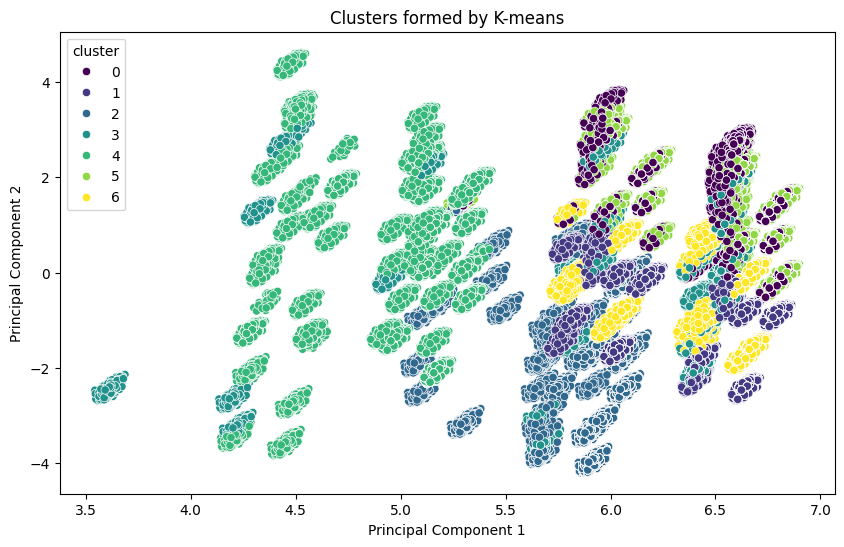

Silhouette Coefficient: 0.02000875338008051
Davies-Bouldin Index: 4.460922934905869


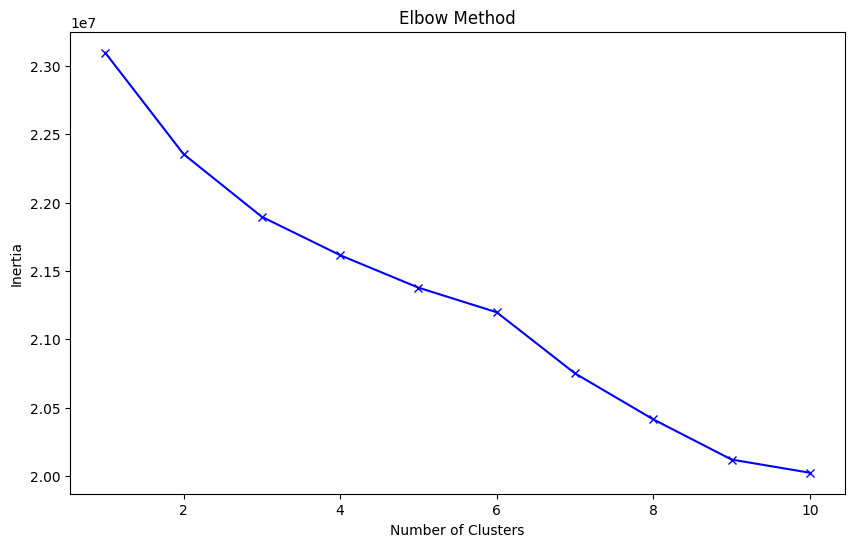

In [36]:
# Drop the 'year', 'month_year' and 'cluster' columns in df_b
df_b = df_b.drop(['year', 'month_year', 'cluster'], axis = 1)
# These are low-information and redundant

# Run K-Means with n_clusters = 7
df_b, pipeline = perform_kmeans_clustering(df_b, n_clusters = 7, random_state = SEED, use_sparse_data = True)

# Evaluate the model
evaluate_clustering_model(pipeline, df_b, max_clusters = 10)

# 11. Modeling: DBSCAN

In [37]:
# Load DF and handle null values and the 'timestamp' variable

# Make a copy of df
df_b = df_original.copy()

# Rename and reorganize columns
df_b = clean_column_names(df_b)

# Drop the 'timestamp' column
df_b = df_b.drop(['timestamp'], axis = 1)

# Handle null values in 'self_employed' - proportional imputation
preprocess_data(df_b)

,gender,country,occupation,self_employed,family_history,treatment,days_indoors,growing_stress,changes_habits,mental_health_history,mood_swings,coping_struggles,work_interest,social_weakness,mental_health_interview,care_options
0,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292359,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292360,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292361,Male,United States,Business,No,Yes,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292362,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes


In [38]:
# Define categorical variables
categorical_features = df_b.columns.tolist()

# Build the pipeline for data transformation
pipeline = Pipeline([
    ('encoder', OneHotEncoder()),  # Transform categorical variables
    ('scaler', StandardScaler(with_mean = False))  # Normalize data for DBSCAN
])

# Apply the transformation pipeline
X_transformed = pipeline.fit_transform(df_b)

# Apply DBSCAN
# Adjust the eps and min_samples parameters as needed
dbscan = DBSCAN(eps=1.0, min_samples=5, metric='euclidean')
clusters = dbscan.fit_predict(X_transformed)

# Add the cluster labels to the DataFrame for analysis
df_b['cluster_dbscan'] = clusters

# Evaluate the results
print(df_b['cluster_dbscan'].value_counts())

# Check the amount of noise (points labeled as -1)
print(f'Points labeled as noise: {(clusters == -1).sum()}')

cluster_dbscan
-1        114951
 9472         41
 6280         41
 4404         41
 7624         41
           ...  
 4664          5
 11412         5
 11411         5
 4663          5
 13092         5
Name: count, Length: 13094, dtype: int64
Points labeled as noise: 114951


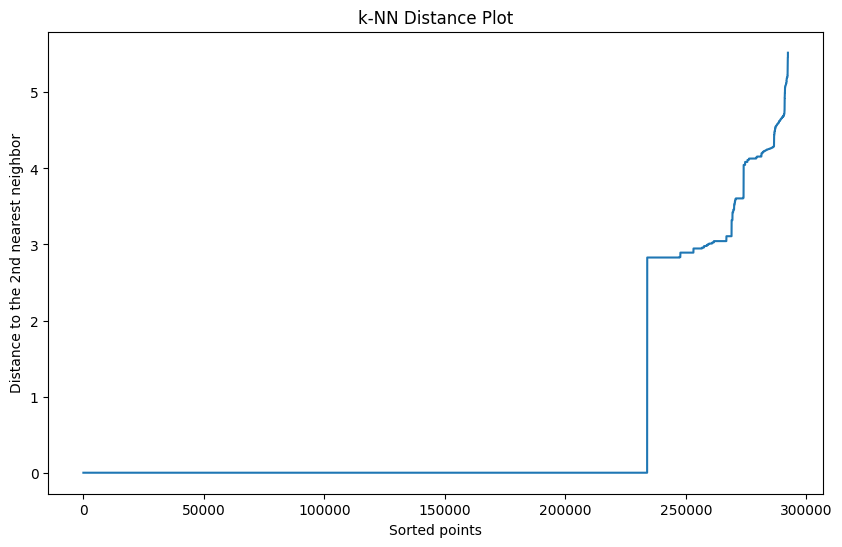

In [39]:
# Evaluate the model
neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X_transformed)
distances, indices = neighbors_fit.kneighbors(X_transformed)

# Sort the distances
distances = np.sort(distances, axis=0)
distances = distances[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('k-NN Distance Plot')
plt.xlabel('Sorted points')
plt.ylabel('Distance to the 2nd nearest neighbor')
plt.show()

DBSCAN was run separately for performance reasons; the output is shown below.

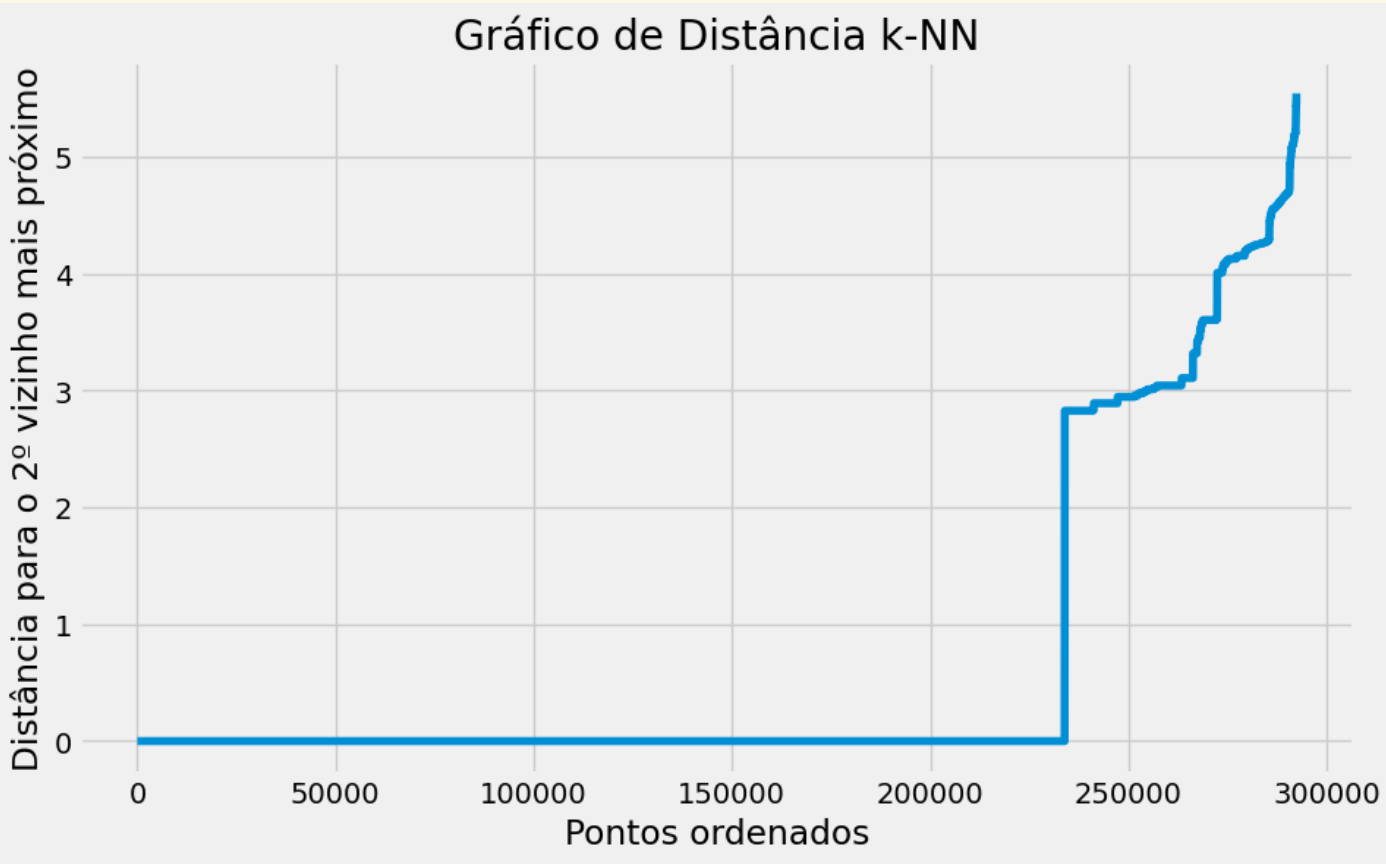

# 12. Conclusions and Notes on the Unsupervised Models

Regarding the unsupervised models applied to the dataset, I was able to observe:

**1. K-Means Clustering**

Model 1 results
* Silhouette Coefficient: around 0.02
* Davies-Bouldin Index: above 4
* Number of clusters: 3

Model 2 results
* Silhouette Coefficient: around 0.02 or below
* Davies-Bouldin Index: above 4
* Number of clusters: 7

Comparison
* Both show silhouette coefficients near zero (around 0.02 or below), indicating poorly defined clusters.
* Neither configuration separated the data well, and changing the number of clusters did not meaningfully improve cluster quality.
* The Davies-Bouldin indices are high for both (above 4), suggesting the clusters are not well separated.

**2. DBSCAN Clustering**
* Only one model was built.
* Most points were classified as noise (-1), with only a few small clusters formed.
* The Silhouette Coefficient and the Davies-Bouldin Index were not computed because of the predominance of noise.
* The cluster visualization showed that many points were classified as noise, indicating that the eps and min_samples parameters need to be better tuned.
* The k-NN distance plot suggested an eps value around 2 to 3, but even with adjustments, many points were still classified as noise.

**Overall conclusion** on the unsupervised models built:
* None of the unsupervised models (K-Means or DBSCAN) managed to form well-defined and separated clusters; both algorithms presented significant challenges in cluster quality.
* Additional parameter adjustments may be needed.

**Suggested next steps:**
* For K-Means, experimenting with different numbers of clusters may help.
* For DBSCAN, adjusting eps and min_samples based on the k-NN distance plot may be useful.
* Considering other clustering algorithms, such as hierarchical clustering or different density-based methods, may be a good approach. In addition, exploring preprocessing and data-transformation techniques may improve the results.